In [4]:
# Import necessary libraries (taken from the multi_analysis script)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from scipy import signal, stats
import pandas as pd
import logging
from typing import Dict, List, Tuple, Optional
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import json
import warnings
import re
import matplotlib.patches as patches

mne.set_log_level("ERROR")
logging.getLogger().setLevel(logging.ERROR)


# Import custom modules
from imagined_vs_actual_analysis_new import ImaginedVsActualAnalyzer, COLORS

In [5]:
# Shared utilities for Entropy / LZC / TAR feature extraction
# Goals:
# Consistent analysis window for task vs baseline (reduces length/PSD-resolution confounds).
# Explicit Welch parameters for reproducibility.
# Correct LZ76 (Kaspar–Schuster style) Lempel–Ziv complexity counting + standard normalization.
#
# Notes:
# We define all Δ features as (task - rest) for consistency.

from typing import Tuple, Optional
import numpy as np
import mne

# Frequency bands used throughout the notebook
BANDS_HZ = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
}

# Consistent analysis window (seconds) within each task epoch.
# PhysioNet MI epochs are often around -1s..4s. A 2s window inside the active period
# provides a consistent duration to compare with baseline fixed-length epochs.
ANALYSIS_TMIN = 0.5
ANALYSIS_TMAX = 2.5
BASELINE_EPOCH_LEN_S = ANALYSIS_TMAX - ANALYSIS_TMIN  # 2.0s
BASELINE_OVERLAP_S   = 1.0

# Welch PSD settings (seconds); will be converted to samples per subject using sfreq
WELCH_WIN_S = 1.0
WELCH_OVERLAP_FRAC = 0.5

DELTA_DIRECTION = "task_minus_rest"  # or "rest_minus_task"
_EPS = 1e-12


def _delta(task_val: float, rest_val: float) -> float:
    """Compute Δ = task - rest (default) or rest - task (legacy)."""
    if DELTA_DIRECTION == "task_minus_rest":
        return float(task_val - rest_val)
    elif DELTA_DIRECTION == "rest_minus_task":
        return float(rest_val - task_val)
    else:
        raise ValueError(f"Unknown DELTA_DIRECTION={DELTA_DIRECTION!r}")


def crop_epochs_safe(epochs: mne.Epochs, tmin: float = ANALYSIS_TMIN, tmax: float = ANALYSIS_TMAX) -> mne.Epochs:
    """Crop epochs to a consistent time window, if possible."""
    ep = epochs.copy()
    try:
        # Only crop if window is within the available epoch times
        if (ep.tmin <= tmin) and (ep.tmax >= tmax):
            ep.crop(tmin=tmin, tmax=tmax)
    except Exception:
        # Fallback: no crop
        pass
    return ep


def make_baseline_epochs(baseline_raw: mne.io.BaseRaw,
                         duration: float = BASELINE_EPOCH_LEN_S,
                         overlap: float = BASELINE_OVERLAP_S) -> mne.Epochs:
    """Create fixed-length baseline epochs with the same duration as the task analysis window."""
    return mne.make_fixed_length_epochs(
        baseline_raw, duration=duration, overlap=overlap, preload=True, verbose=False
    )


def welch_psd_epochs(epochs: mne.Epochs,
                     fmin: float,
                     fmax: float,
                     win_s: float = WELCH_WIN_S,
                     overlap_frac: float = WELCH_OVERLAP_FRAC) -> Tuple[np.ndarray, np.ndarray]:
    """Compute Welch PSD for epochs with explicit parameters for reproducibility.

    Returns:
      psds: shape (n_epochs, n_channels, n_freqs)
      freqs: shape (n_freqs,)
    """
    data = epochs.get_data()  # (..., n_times)
    sfreq = float(epochs.info["sfreq"])
    n_times = data.shape[-1]

    n_per_seg = int(round(win_s * sfreq))
    n_per_seg = max(16, min(n_per_seg, n_times))  # keep reasonable and <= epoch length

    # Use power-of-two n_fft >= n_per_seg for FFT efficiency & stable frequency grid
    n_fft = 1
    while n_fft < n_per_seg:
        n_fft *= 2

    n_overlap = int(round(overlap_frac * n_per_seg))
    n_overlap = min(n_overlap, n_per_seg - 1)

    psds, freqs = mne.time_frequency.psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        n_fft=n_fft,
        n_overlap=n_overlap,
        n_per_seg=n_per_seg,
        average="mean",
        verbose=False,
    )
    return psds, freqs


def binarize_median(x: np.ndarray) -> np.ndarray:
    """Median-based binarization (robust to outliers) for LZC."""
    med = np.median(x)
    return (x > med).astype(np.uint8)


# **Code for calculating Power Spectral Entropy Differences between Imagined and Actual Movements**
Power Spectral Entropy (PSE) measures the complexity or "peakiness" of a signal’s power spectral density (PSD) by applying Shannon entropy to the frequency domain. A flat, complex signal like white noise yields higher entropy, while a simple signal with sharp peaks has lower entropy. We use ΔH (task entropy - baseline entropy) instead of just the task entropy. Negative ∆H values indicate increased signal complexity during
motor imagery (potentially reflecting poor BCI control), while positive values suggest simplified, more predictable neural patterns (favorable for BCI performance)




In [6]:
# Spectral Entropy (PSE) feature extraction
# We compute spectral entropy within a band using Welch PSD, then average across channels and epochs.
# ΔH is computed relative to baseline with a consistent analysis window.

import numpy as np
import mne
from typing import Dict


def spectral_entropy_from_psd(psd: np.ndarray, eps: float = _EPS) -> float:
    """Spectral entropy of a 1D PSD vector, normalized to [0, 1]."""
    p = psd.astype(float) + eps
    p /= p.sum()
    H = -np.sum(p * np.log2(p))
    return float(H / np.log2(p.size))


def band_entropy_from_epochs(epochs: mne.Epochs, fmin: float, fmax: float) -> np.ndarray:
    """Return per-epoch spectral entropy (channels averaged) for the specified band."""
    epochs = crop_epochs_safe(epochs)
    psds, _freqs = welch_psd_epochs(epochs, fmin=fmin, fmax=fmax)
    # psds: (n_epochs, n_channels, n_freqs)
    # Convert each channel PSD into a distribution over frequency bins and compute entropy
    ent = np.zeros((psds.shape[0], psds.shape[1]), dtype=float)
    for e in range(psds.shape[0]):
        for ch in range(psds.shape[1]):
            ent[e, ch] = spectral_entropy_from_psd(psds[e, ch])
    return ent.mean(axis=1)  # (n_epochs,)


def entropy_task_rest(task_epochs: mne.Epochs, baseline_raw: mne.io.BaseRaw,
                      fmin: float, fmax: float) -> Dict[str, float]:
    """Compute task vs rest entropy metrics for one condition.

    Returns:
      H_task, H_rest, ΔH (per DELTA_DIRECTION)
    """
    task_epochs = crop_epochs_safe(task_epochs)
    baseline_epochs = make_baseline_epochs(baseline_raw)

    H_task = float(band_entropy_from_epochs(task_epochs, fmin, fmax).mean())
    H_rest = float(band_entropy_from_epochs(baseline_epochs, fmin, fmax).mean())
    return {"H_task": H_task, "H_rest": H_rest, "ΔH": _delta(H_task, H_rest)}


def imagined_real_entropy_features(analyzer: ImaginedVsActualAnalyzer,
                                  band: str = "beta",
                                  max_epochs: int = 20) -> Dict[str, Dict[str, float]]:
    """Compute entropy features for imagined vs real tasks.

    Output per task:
      ΔH_real, ΔH_imagined, gap = ΔH_real - ΔH_imagined,
      H_baseline (absolute resting entropy)
    """
    fmin, fmax = BANDS_HZ[band]
    baseline_raw = analyzer.data["baseline_eyes_open"]["raw"]

    # Precompute baseline entropy once for this band
    base_epochs_tmp = make_baseline_epochs(baseline_raw)
    H_baseline = float(band_entropy_from_epochs(base_epochs_tmp, fmin, fmax).mean())

    results: Dict[str, Dict[str, float]] = {}
    for pair in analyzer.task_pairs:
        real_key = f"{pair['name']}_real"
        imag_key = f"{pair['name']}_imagined"
        if real_key not in analyzer.data or imag_key not in analyzer.data:
            continue

        real_epochs = analyzer.data[real_key]["epochs"][:max_epochs]
        imag_epochs = analyzer.data[imag_key]["epochs"][:max_epochs]
        if len(real_epochs) < 5 or len(imag_epochs) < 5:
            continue

        real_m = entropy_task_rest(real_epochs, baseline_raw, fmin, fmax)
        imag_m = entropy_task_rest(imag_epochs, baseline_raw, fmin, fmax)

        results[pair["name"]] = {
            "ΔH_real":     real_m["ΔH"],
            "ΔH_imagined": imag_m["ΔH"],
            "gap":         real_m["ΔH"] - imag_m["ΔH"],
            "H_baseline":  H_baseline,
        }
    return results


# Quick sanity check on one subject (optional)
# analyzer = ImaginedVsActualAnalyzer(subject_id="S026")
# analyzer.load_and_preprocess_data()
# beta_entropy = imagined_real_entropy_features(analyzer, band="beta")
# alpha_entropy = imagined_real_entropy_features(analyzer, band="alpha")
# print("Entropy features computed. Example task:", next(iter(beta_entropy.items()), None))


# Backwards-compatible alias (older code used this name)
imagined_real_entropy_gap = imagined_real_entropy_features


## **Code for Calculating Brainwave Signal Lempel-Ziv Complexity**

Lempel-Ziv complexity measures how frequently new patterns appear as a sequence unfolds. Basically how often new trends appear in the brainwaves/signals. We use ΔLZC (task LZC - baseline LZC) instead of just the task LZC. We are primarily interested in the beta ΔLZC (task - resting):

Low LZC → repetitive, stereotyped neural activity (favorable for BCI decoding)

High LZC → noisy motor inhibition → unstable control

In [7]:
# Lempel–Ziv Complexity (LZC; LZ76) feature extraction
# We use a correct Kaspar–Schuster style LZ76 phrase-count algorithm and standard normalization:
#   LZC_norm = c(n) * log2(n) / n
# where c(n) is the LZ76 phrase count on a binarized signal.

import numpy as np
import mne
from typing import Dict


def lz76_count(binary_sequence: np.ndarray) -> int:
    """Kaspar & Schuster style LZ76 phrase count c(n).

    Input:
      binary_sequence: 1D array of {0,1} values.
    """
    s = np.asarray(binary_sequence, dtype=np.uint8)
    n = s.size
    if n == 0:
        return 0
    if n == 1:
        return 1

    i, l = 0, 1
    k, k_max = 1, 1
    c = 1

    while True:
        if l + k > n or i + k > n:
            c += 1
            break

        if s[i + k - 1] == s[l + k - 1]:
            k += 1
            if l + k > n:
                c += 1
                break
        else:
            k_max = max(k_max, k)
            i += 1
            if i == l:
                c += 1
                l += k_max
                if l >= n:
                    break
                i, k, k_max = 0, 1, 1
            else:
                k = 1

    return int(c)


def lz76_normalized(binary_sequence: np.ndarray) -> float:
    """Normalized LZ76 complexity."""
    n = int(len(binary_sequence))
    if n < 2:
        return 0.0
    return float(lz76_count(binary_sequence) * (np.log2(n) / n))


def band_lzc_from_epochs(epochs: mne.Epochs, fmin: float, fmax: float) -> np.ndarray:
    """Return per-epoch LZC (channels averaged) for a filtered band."""
    epochs = crop_epochs_safe(epochs)
    # Band-pass filter the epochs data (epoch filtering is convenient but still keep epochs long enough)
    data = epochs.copy().filter(
        fmin, fmax,
        fir_design="firwin",
        phase="zero",
        verbose=False
    ).get_data()  # (n_epochs, n_channels, n_times)

    lzc_epoch = np.zeros((data.shape[0],), dtype=float)
    for e in range(data.shape[0]):
        ch_vals = []
        for ch in range(data.shape[1]):
            bits = binarize_median(data[e, ch])
            ch_vals.append(lz76_normalized(bits))
        lzc_epoch[e] = float(np.mean(ch_vals))
    return lzc_epoch


def lzc_task_rest(task_epochs: mne.Epochs, baseline_raw: mne.io.BaseRaw,
                  fmin: float, fmax: float) -> Dict[str, float]:
    """Compute task vs rest LZC metrics for one condition."""
    task_epochs = crop_epochs_safe(task_epochs)
    baseline_epochs = make_baseline_epochs(baseline_raw)

    L_task = float(band_lzc_from_epochs(task_epochs, fmin, fmax).mean())
    L_rest = float(band_lzc_from_epochs(baseline_epochs, fmin, fmax).mean())
    return {"LZC_task": L_task, "LZC_rest": L_rest, "ΔLZC": _delta(L_task, L_rest)}


def imagined_real_lzc_features(analyzer: ImaginedVsActualAnalyzer,
                              band: str = "beta",
                              max_epochs: int = 20) -> Dict[str, Dict[str, float]]:
    """Compute ΔLZC features for imagined vs real movement, plus baseline LZC."""
    fmin, fmax = BANDS_HZ[band]
    baseline_raw = analyzer.data["baseline_eyes_open"]["raw"]

    base_epochs_tmp = make_baseline_epochs(baseline_raw)
    LZC_baseline = float(band_lzc_from_epochs(base_epochs_tmp, fmin, fmax).mean())

    results: Dict[str, Dict[str, float]] = {}
    for pair in analyzer.task_pairs:
        real_key = f"{pair['name']}_real"
        imag_key = f"{pair['name']}_imagined"
        if real_key not in analyzer.data or imag_key not in analyzer.data:
            continue

        real_epochs = analyzer.data[real_key]["epochs"][:max_epochs]
        imag_epochs = analyzer.data[imag_key]["epochs"][:max_epochs]
        if len(real_epochs) < 5 or len(imag_epochs) < 5:
            continue

        real_m = lzc_task_rest(real_epochs, baseline_raw, fmin, fmax)
        imag_m = lzc_task_rest(imag_epochs, baseline_raw, fmin, fmax)

        results[pair["name"]] = {
            "ΔLZC_real":     real_m["ΔLZC"],
            "ΔLZC_imagined": imag_m["ΔLZC"],
            "gap":           real_m["ΔLZC"] - imag_m["ΔLZC"],
            "LZC_baseline":  LZC_baseline,
        }
    return results


# Quick sanity checks on synthetic signals (optional)
# rng = np.random.default_rng(0)
# const = np.zeros(512)
# noise = rng.standard_normal(512)
# bits_const = binarize_median(const)
# bits_noise = binarize_median(noise)
# print("LZC const:", lz76_normalized(bits_const), "LZC noise:", lz76_normalized(bits_noise))


# Code for computing Theta/Alpha Power Ratio

Activity in the Theta band (4-8Hz) is correlated with memory encoding and retrieval, spatial navigation, cognitive control, and emotional processing (drowsiness, deep meditation, REM sleep, cognitive load), while activity in the Alpha band (8-12Hz), specifically the Mu Rhythm located in that range, is correlated with readiness for cognitive tasks. Both show a large spike in ERS followed by a spike in ERD when a person begins the process of doing/imagining a basic movement. Multiple studies have shown low Theta/Alpha power during motor imagery to correlate in some way to better MI BCI compatibility. 

We use ΔTAR (task TAR - baseline TAR) instead of just the task TAR

High θ/α → poor attentional control, too much anxiousness/stress (often bad for MI BCIs)

Low θ/α with alpha ERD → relaxed yet focused, BCI-friendly users

In [8]:
# Theta/Alpha Ratio (TAR) feature extraction
# We compute band powers as the integral of PSD (trapz) to represent true band power.
# TAR = P_theta / P_alpha
# ΔTAR computed relative to baseline (consistent analysis window).

import numpy as np
import mne
from typing import Dict


def bandpower_from_epochs(epochs: mne.Epochs, fmin: float, fmax: float) -> float:
    """Compute average band power (integral of PSD over frequency) across channels/epochs."""
    epochs = crop_epochs_safe(epochs)
    psds, freqs = welch_psd_epochs(epochs, fmin=fmin, fmax=fmax)
    # Integrate PSD over frequency bins to get band power per epoch/channel
    bp = np.trapz(psds, freqs, axis=-1)  # (n_epochs, n_channels)
    return float(bp.mean())


def theta_alpha_ratio(epochs: mne.Epochs) -> float:
    """Theta/Alpha ratio using integrated band powers."""
    p_theta = bandpower_from_epochs(epochs, *BANDS_HZ["theta"])
    p_alpha = bandpower_from_epochs(epochs, *BANDS_HZ["alpha"])
    return float(p_theta / (p_alpha + _EPS))


def tar_task_rest(task_epochs: mne.Epochs, baseline_raw: mne.io.BaseRaw) -> Dict[str, float]:
    task_epochs = crop_epochs_safe(task_epochs)
    baseline_epochs = make_baseline_epochs(baseline_raw)

    TAR_task = float(theta_alpha_ratio(task_epochs))
    TAR_rest = float(theta_alpha_ratio(baseline_epochs))
    return {"TAR_task": TAR_task, "TAR_rest": TAR_rest, "ΔTAR": _delta(TAR_task, TAR_rest)}


def imagined_real_theta_alpha_features(analyzer: ImaginedVsActualAnalyzer,
                                      max_epochs: int = 20) -> Dict[str, Dict[str, float]]:
    """Compute TAR features for imagined vs real tasks.

    Output per task:
      ΔTAR_real, ΔTAR_imagined, gap = ΔTAR_real - ΔTAR_imagined,
      TAR_baseline (absolute resting TAR)
    """
    baseline_raw = analyzer.data["baseline_eyes_open"]["raw"]

    # Precompute baseline TAR once per subject
    base_epochs_tmp = make_baseline_epochs(baseline_raw)
    TAR_baseline = float(theta_alpha_ratio(base_epochs_tmp))

    results: Dict[str, Dict[str, float]] = {}
    for pair in analyzer.task_pairs:
        real_key = f"{pair['name']}_real"
        imag_key = f"{pair['name']}_imagined"
        if real_key not in analyzer.data or imag_key not in analyzer.data:
            continue

        real_epochs = analyzer.data[real_key]["epochs"][:max_epochs]
        imag_epochs = analyzer.data[imag_key]["epochs"][:max_epochs]
        if len(real_epochs) < 5 or len(imag_epochs) < 5:
            continue

        real_m = tar_task_rest(real_epochs, baseline_raw)
        imag_m = tar_task_rest(imag_epochs, baseline_raw)

        results[pair["name"]] = {
            "ΔTAR_real":     real_m["ΔTAR"],
            "ΔTAR_imagined": imag_m["ΔTAR"],
            "gap":           real_m["ΔTAR"] - imag_m["ΔTAR"],
            "TAR_baseline":  TAR_baseline,
        }
    return results


# Quick sanity check on one subject (optional)
# analyzer = ImaginedVsActualAnalyzer(subject_id="S001")
# analyzer.load_and_preprocess_data()
# tar = imagined_real_theta_alpha_features(analyzer)
# print("TAR features computed. Example task:", next(iter(tar.items()), None))


## Code for generating my dataset

In [9]:
"""
# Generate comprehensive dataset for all subjects
import warnings
warnings.filterwarnings('ignore')

def process_subject(subject_id: str) -> Dict:
    
    #Process a single subject and extract all EEG metrics.
    #Returns a dictionary with all features.
    
    try:
        print(f"Processing {subject_id}...")
        analyzer = ImaginedVsActualAnalyzer(subject_id=subject_id)
        analyzer.load_and_preprocess_data()
        
        # Compute all features
        beta_entropy = imagined_real_entropy_features(analyzer, band="beta", max_epochs=20)
        alpha_entropy = imagined_real_entropy_features(analyzer, band="alpha", max_epochs=20)
        beta_lzc = imagined_real_lzc_features(analyzer, band="beta", max_epochs=20)
        alpha_lzc = imagined_real_lzc_features(analyzer, band="alpha", max_epochs=20)
        tar_features = imagined_real_theta_alpha_features(analyzer, max_epochs=20)
        
        # Compile results into flat dictionary
        results = {'subject_id': subject_id}

        # ── Resting (baseline) values – subject-level, extract from first task ──
        # H_baseline and LZC_baseline are identical across task entries for a
        # given band, so we just grab them from the first available task.
        first_beta_entropy = next(iter(beta_entropy.values()), {})
        first_alpha_entropy = next(iter(alpha_entropy.values()), {})
        first_beta_lzc = next(iter(beta_lzc.values()), {})
        first_alpha_lzc = next(iter(alpha_lzc.values()), {})

        results['resting_beta_entropy']  = first_beta_entropy.get('H_baseline',  None)
        results['resting_alpha_entropy'] = first_alpha_entropy.get('H_baseline', None)
        results['resting_beta_lzc']      = first_beta_lzc.get('LZC_baseline',    None)
        results['resting_alpha_lzc']     = first_alpha_lzc.get('LZC_baseline',   None)

        # TAR_baseline is identical across tasks, so grab from first available task entry
        first_tar = next(iter(tar_features.values()), {})
        results['resting_tar'] = first_tar.get('TAR_baseline', None)
        
        # Extract per-task features
        for task_name in beta_entropy.keys():
            # Beta band spectral entropy
            if task_name in beta_entropy:
                results[f'{task_name}_beta_entropy_real'] = beta_entropy[task_name]['ΔH_real']
                results[f'{task_name}_beta_entropy_imagined'] = beta_entropy[task_name]['ΔH_imagined']
                results[f'{task_name}_beta_entropy_gap'] = beta_entropy[task_name]['gap']
            
            # Alpha band spectral entropy
            if task_name in alpha_entropy:
                results[f'{task_name}_alpha_entropy_real'] = alpha_entropy[task_name]['ΔH_real']
                results[f'{task_name}_alpha_entropy_imagined'] = alpha_entropy[task_name]['ΔH_imagined']
                results[f'{task_name}_alpha_entropy_gap'] = alpha_entropy[task_name]['gap']
            
            # Beta band LZC
            if task_name in beta_lzc:
                results[f'{task_name}_beta_lzc_real'] = beta_lzc[task_name]['ΔLZC_real']
                results[f'{task_name}_beta_lzc_imagined'] = beta_lzc[task_name]['ΔLZC_imagined']
                results[f'{task_name}_beta_lzc_gap'] = beta_lzc[task_name]['gap']
            
            # Alpha band LZC
            if task_name in alpha_lzc:
                results[f'{task_name}_alpha_lzc_real'] = alpha_lzc[task_name]['ΔLZC_real']
                results[f'{task_name}_alpha_lzc_imagined'] = alpha_lzc[task_name]['ΔLZC_imagined']
                results[f'{task_name}_alpha_lzc_gap'] = alpha_lzc[task_name]['gap']
            
            # Theta/Alpha ratio
            if task_name in tar_features:
                results[f'{task_name}_tar_real'] = tar_features[task_name]['ΔTAR_real']
                results[f'{task_name}_tar_imagined'] = tar_features[task_name]['ΔTAR_imagined']
                results[f'{task_name}_tar_gap'] = tar_features[task_name]['gap']
        
        print(f"✓ {subject_id} completed")
        return results
        
    except Exception as e:
        print(f"✗ {subject_id} failed: {str(e)}")
        return {'subject_id': subject_id, 'error': str(e)}


# Process all subjects (S001 to S109)
all_results = []
for i in range(1, 110):
    subject_id = f"S{i:03d}"
    result = process_subject(subject_id)
    all_results.append(result)

# Create DataFrame
df_eeg_features = pd.DataFrame(all_results)
df_eeg_features.set_index('subject_id', inplace=True)

# Display dataset info
print("\n" + "="*60)
print("DATASET GENERATION COMPLETE")
print("="*60)
print(f"Total subjects: {len(df_eeg_features)}")
print(f"Total features: {len(df_eeg_features.columns)}")
print(f"\nDataset shape: {df_eeg_features.shape}")
print(f"\nFirst few rows:")
print(df_eeg_features.head())

# Save to CSV
output_path = 'eeg_features_andrew_new.csv'
df_eeg_features.to_csv(output_path)
print(f"\n✓ Dataset saved to: {output_path}")
"""


'\n# Generate comprehensive dataset for all subjects\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\ndef process_subject(subject_id: str) -> Dict:\n    \n    #Process a single subject and extract all EEG metrics.\n    #Returns a dictionary with all features.\n    \n    try:\n        print(f"Processing {subject_id}...")\n        analyzer = ImaginedVsActualAnalyzer(subject_id=subject_id)\n        analyzer.load_and_preprocess_data()\n        \n        # Compute all features\n        beta_entropy = imagined_real_entropy_features(analyzer, band="beta", max_epochs=20)\n        alpha_entropy = imagined_real_entropy_features(analyzer, band="alpha", max_epochs=20)\n        beta_lzc = imagined_real_lzc_features(analyzer, band="beta", max_epochs=20)\n        alpha_lzc = imagined_real_lzc_features(analyzer, band="alpha", max_epochs=20)\n        tar_features = imagined_real_theta_alpha_features(analyzer, max_epochs=20)\n        \n        # Compile results into flat dictionary\n        resu

## Code to make my dataset more compact by removing the grouping via trial columns

In [10]:

df = pd.read_csv("eeg_features_andrew_new.csv")

def aggregate_trials(df, pattern):
    cols = [c for c in df.columns if re.search(pattern, c)]
    if len(cols) == 0:
        raise ValueError(f"No columns matched pattern: {pattern}")
    return df[cols].mean(axis=1)

compact = pd.DataFrame()
compact["subject_id"] = df["subject_id"]

tasks = {
    "FF": "Fists/Feet",
    "LRF": "Left/Right Fist"
}

bands = ["alpha", "beta"]
features = ["entropy", "lzc"]
conditions = ["real", "imagined", "gap"]
trials = [1, 2, 3]


for short, long in tasks.items():
    for band in bands:
        for feat in features:
            for cond in conditions:
                pattern = (
                    rf"{long} [1-3]_{band}_{feat}_{cond}"
                )
                colname = f"{short}_{band}_{feat}_{cond}"
                compact[colname] = aggregate_trials(df, pattern)
for short, long in tasks.items():
    for cond in conditions:
        pattern = rf"{long} [1-3]_tar_{cond}"
        colname = f"{short}_tar_{cond}"
        compact[colname] = aggregate_trials(df, pattern)

# ── Resting baselines: subject-level columns, pass through directly ──────────
# These columns already exist as single values per subject in the raw CSV.
for col in ["resting_beta_entropy", "resting_alpha_entropy",
            "resting_beta_lzc",     "resting_alpha_lzc",
            "resting_tar"]:
    if col in df.columns:
        compact[col] = df[col].values
    else:
        compact[col] = None   # graceful fallback if CSV pre-dates this change

final_columns = [
    "subject_id",

    # Per-task task-modulation features
    "FF_alpha_entropy_gap","FF_alpha_entropy_imagined","FF_alpha_entropy_real",
    "FF_alpha_lzc_gap","FF_alpha_lzc_imagined","FF_alpha_lzc_real",
    "FF_beta_entropy_gap","FF_beta_entropy_imagined","FF_beta_entropy_real",
    "FF_beta_lzc_gap","FF_beta_lzc_imagined","FF_beta_lzc_real",

    "LRF_alpha_entropy_gap","LRF_alpha_entropy_imagined","LRF_alpha_entropy_real",
    "LRF_alpha_lzc_gap","LRF_alpha_lzc_imagined","LRF_alpha_lzc_real",
    "LRF_beta_entropy_gap","LRF_beta_entropy_imagined","LRF_beta_entropy_real",
    "LRF_beta_lzc_gap","LRF_beta_lzc_imagined","LRF_beta_lzc_real",

    "FF_tar_gap","FF_tar_imagined","FF_tar_real",
    "LRF_tar_gap","LRF_tar_imagined","LRF_tar_real",

    # Resting baseline features (subject-level, not task-averaged)
    "resting_beta_entropy",
    "resting_alpha_entropy",
    "resting_beta_lzc",
    "resting_alpha_lzc",
    "resting_tar",
]

compact = compact[final_columns]
compact.to_csv("eeg_features_andrew_compact_new.csv", index=False)


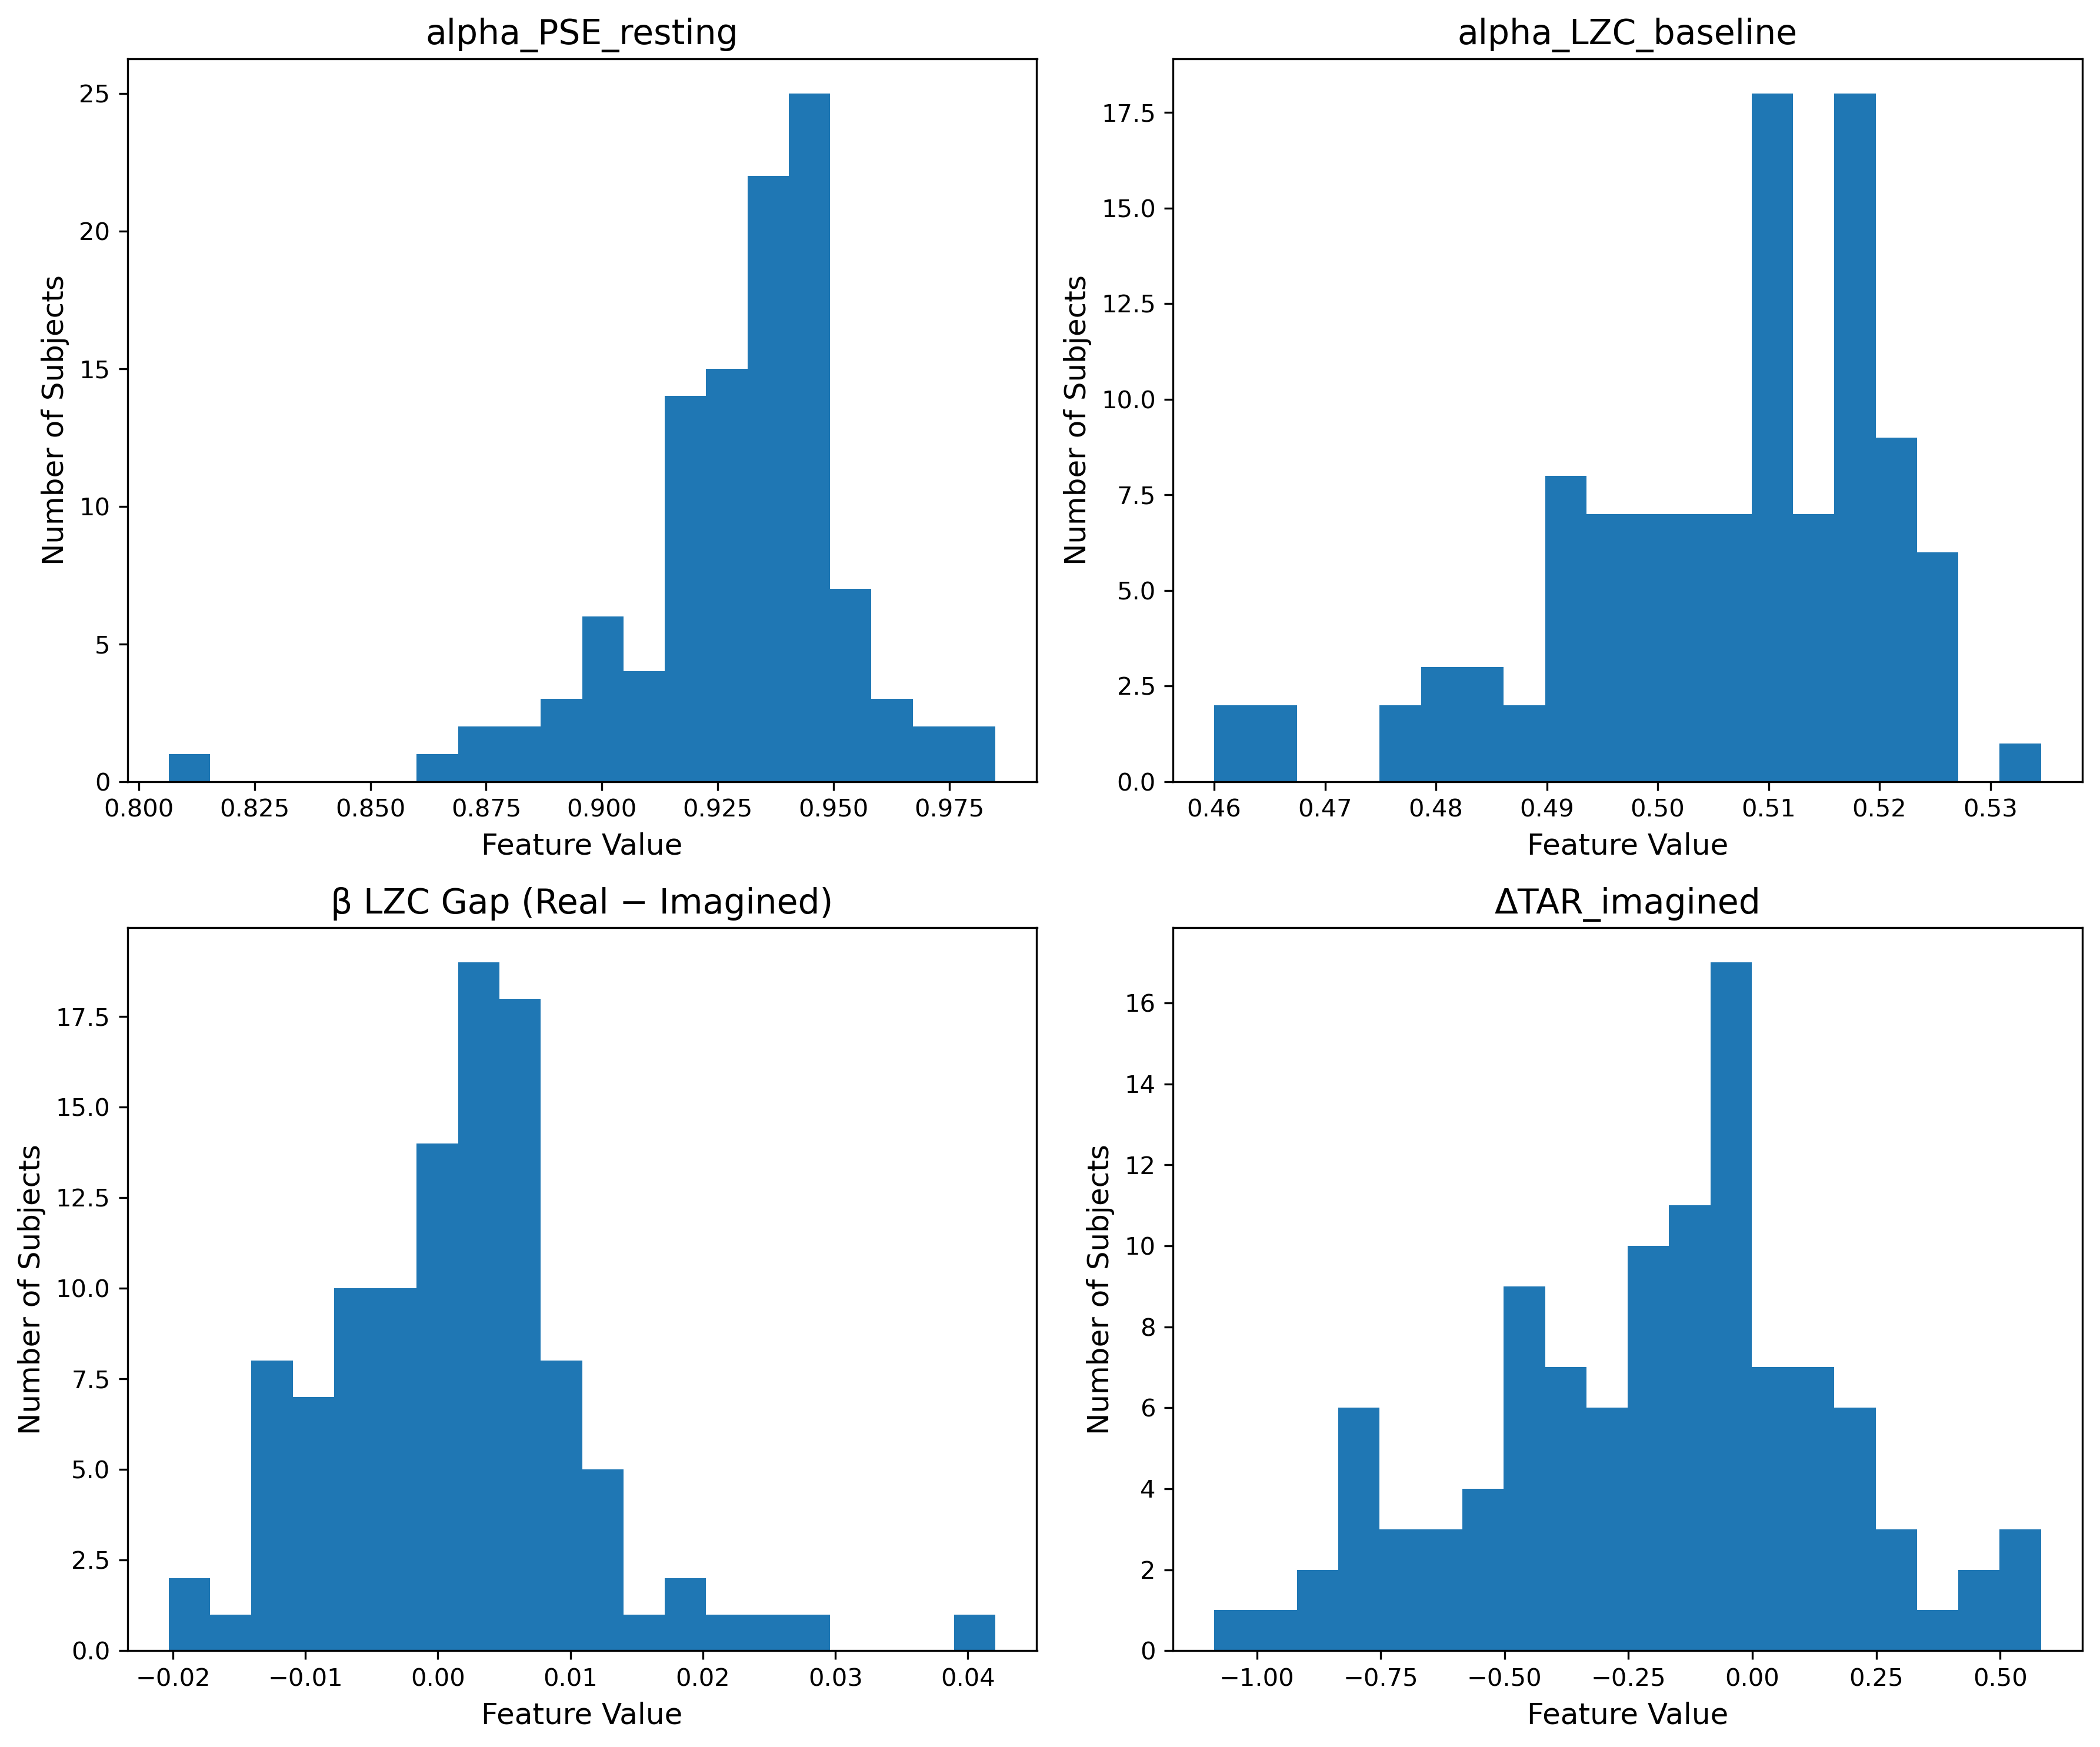

In [11]:
df = pd.read_csv("eeg_features_andrew_compact_new.csv")

# Select features
features = {
    "alpha_PSE_resting": "resting_alpha_entropy",
    "alpha_LZC_baseline": "resting_alpha_lzc",
    "β LZC Gap (Real − Imagined)": "LRF_beta_lzc_gap",
    "ΔTAR_imagined": "LRF_tar_imagined"
}

# Plot histograms
plt.figure(figsize=(12, 10))

for i, (label, col) in enumerate(features.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col].dropna(), bins=20)
    plt.title(label)
    plt.xlabel("Feature Value")
    plt.ylabel("Number of Subjects")

plt.tight_layout()
plt.show()

To create visualizations that show how low and high feature values are reflected in the EEG data, I found the subjects with the 3 lowest and highest values per feature. (I later decided to do the #1 lowest and highest values)

In [12]:
df = pd.read_csv("eeg_features_andrew_compact_new.csv")

lzc_feature = "LRF_beta_lzc_imagined"
lzc_high_subj = df.nlargest(3, lzc_feature)["subject_id"].tolist()
lzc_low_subj  = df.nsmallest(3, lzc_feature)["subject_id"].tolist()
print("LRF_beta_lzc_imagined_High:", lzc_high_subj)
print("LRF_beta_lzc_imagined_Low:", lzc_low_subj)

entropy_feature = "LRF_beta_entropy_imagined"
entropy_high_subj = df.nlargest(3, entropy_feature)["subject_id"].tolist()
entropy_low_subj  = df.nsmallest(3, entropy_feature)["subject_id"].tolist()
print("LRF_beta_entropy_imagined_High:", entropy_high_subj)
print("LRF_beta_entropy_imagined_Low:", entropy_low_subj)

lzh_gap_feature = "LRF_beta_lzc_gap"
lzc_gap_high_subj = df.nlargest(3, lzh_gap_feature)["subject_id"].tolist()
lzc_gap_low_subj  = df.nsmallest(3, lzh_gap_feature)["subject_id"].tolist()
print("LRF_beta_lzc_gap_High:", lzc_gap_high_subj)
print("LRF_beta_lzc_gap_Low:", lzc_gap_low_subj)

tar_feature = "LRF_tar_imagined"
tar_high_subj = df.nlargest(3, tar_feature)["subject_id"].tolist()
tar_low_subj  = df.nsmallest(3, tar_feature)["subject_id"].tolist()
print("LRF_tar_imagined_High:", tar_high_subj)
print("LRF_tar_imagined_Low:", tar_low_subj)

# Resting baseline extremes 
print()
for col in ["resting_beta_entropy", "resting_alpha_entropy",
            "resting_beta_lzc",     "resting_alpha_lzc",
            "resting_tar"]:
    if col not in df.columns:
        print(f"  [SKIP] {col} not found in dataset (re-generate CSV first)")
        continue
    high = df.nlargest(3,  col)["subject_id"].tolist()
    low  = df.nsmallest(3, col)["subject_id"].tolist()
    print(f"{col}_High: {high}")
    print(f"{col}_Low:  {low}")
 


LRF_beta_lzc_imagined_High: ['S100', 'S088', 'S092']
LRF_beta_lzc_imagined_Low: ['S094', 'S031', 'S015']
LRF_beta_entropy_imagined_High: ['S042', 'S074', 'S041']
LRF_beta_entropy_imagined_Low: ['S094', 'S031', 'S016']
LRF_beta_lzc_gap_High: ['S042', 'S033', 'S015']
LRF_beta_lzc_gap_Low: ['S003', 'S063', 'S022']
LRF_tar_imagined_High: ['S086', 'S004', 'S105']
LRF_tar_imagined_Low: ['S018', 'S006', 'S078']

resting_beta_entropy_High: ['S089', 'S067', 'S016']
resting_beta_entropy_Low:  ['S042', 'S095', 'S074']
resting_alpha_entropy_High: ['S067', 'S089', 'S051']
resting_alpha_entropy_Low:  ['S042', 'S031', 'S034']
resting_beta_lzc_High: ['S027', 'S069', 'S017']
resting_beta_lzc_Low:  ['S042', 'S033', 'S083']
resting_alpha_lzc_High: ['S018', 'S032', 'S091']
resting_alpha_lzc_Low:  ['S048', 'S100', 'S033']
resting_tar_High: ['S046', 'S006', 'S012']
resting_tar_Low:  ['S048', 'S100', 'S025']


# Plotting Visualizations for Low vs High

I took the most extreme subject from each high/low list for all features.
For each feature, loaded appropriate subjects and generated relevant visualizations:

LRF Motor Imagery Alpha Entropy features → timeseries plots

LRF Motor Imagery Alpha LZC features → timeseries plots

LRF Motor Imagery Alpha LZC gap features → real vs imagined comparison plots

LRF Motor Imagery TAR features → theta/alpha bar graphs

In [13]:
# LZC Recurrence Plot Visualization
# Recurrence plots show repeated patterns in time-series data. High LZC (complex,
# random signals) produce diffuse, scattered recurrence patterns. Low LZC (simple,
# repetitive signals) show clear diagonal/block structures indicating predictable
# recurring patterns. This makes LZC differences visually interpretable.

REC_THRESHOLD_PERCENTILE = 5   # smaller -> less busy plots; 5% often reads better than 10%
REC_INTERP = "nearest"         # crisp pixels
REC_ASPECT = "equal"           # square matrix looks square


def compute_recurrence_matrix(signal, threshold_percentile=REC_THRESHOLD_PERCENTILE):
    """
    Build a binary recurrence matrix R where R[i,j]=1 if |x[i]-x[j]| <= epsilon.
    epsilon is chosen as a percentile of pairwise distances (keeps recurrence rate comparable).
    """
    # z-score so amplitudes don't change distance scaling
    signal = np.asarray(signal, dtype=float)
    signal = (signal - signal.mean()) / (signal.std() + 1e-10)

    n = len(signal)
    dist = np.abs(signal[:, None] - signal[None, :])
    eps = np.percentile(dist, threshold_percentile)
    rec = (dist <= eps).astype(float)
    return rec


def pick_representative_epoch_by_lzc(epochs, fmin=8, fmax=13, pick="C3"):
    """
    Choose an epoch whose (channel-level) LZC is closest to the subject's mean LZC.
    This avoids showing a weird/unrepresentative epoch (common when using epoch 0).
    Uses the SAME band and binarization logic as the feature code.
    """
    ep = crop_epochs_safe(epochs)  # <-- aligns viz window with feature window
    ep_f = ep.copy().filter(fmin, fmax, verbose=False)

    # data: (n_epochs, n_channels, n_times). pick single channel
    data = ep_f.get_data(picks=[pick])[:, 0, :]

    # compute per-epoch LZC on that channel
    lz_per_epoch = np.array([lz76_normalized(binarize_median(x)) for x in data], dtype=float)

    mean_lz = float(lz_per_epoch.mean())
    idx = int(np.argmin(np.abs(lz_per_epoch - mean_lz)))

    return data[idx], float(lz_per_epoch[idx]), mean_lz

def plot_lzc_recurrence(epochs, subject_id, ax=None, cmap="binary",
                        fmin=8, fmax=13, pick="C3",
                        n_samples=None,
                        threshold_percentile=REC_THRESHOLD_PERCENTILE):
    """
    Plot recurrence matrix for a representative alpha-band epoch.
    n_samples: if set, trims the 1D signal to that exact length (for fair comparisons).
    """
    sig, lz_rep, lz_mean = pick_representative_epoch_by_lzc(
        epochs, fmin=fmin, fmax=fmax, pick=pick
    )
    # trim to fixed length if requested (important for high-vs-low comparison)
    if n_samples is not None:
        sig = sig[:int(n_samples)]
    rec = compute_recurrence_matrix(sig, threshold_percentile=threshold_percentile)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(rec, cmap=cmap, origin="lower",
              aspect=REC_ASPECT, interpolation=REC_INTERP)
    ax.set_xlabel("Time Index", fontsize=9)
    ax.set_ylabel("Time Index", fontsize=9)
    ax.set_title(f"{subject_id}  (rep LZC={lz_rep:.3f}, mean={lz_mean:.3f})", fontsize=10)

    return ax, rec


def plot_lzc_recurrence_pair(epochs_high, subj_high, epochs_low, subj_low, feature_name,
                            fmin=8, fmax=13, pick="C3",
                            threshold_percentile=REC_THRESHOLD_PERCENTILE):
    """
    Side-by-side recurrence plots for HIGH vs LOW LZC subjects, aligned in:
      - band,
      - time window,
      - representative epoch choice,
      - recurrence threshold,
      - matrix size,
      - and subplot spacing.
    """
    # Get representative signals first so we can force SAME length
    sig_high, _, _ = pick_representative_epoch_by_lzc(epochs_high, fmin=fmin, fmax=fmax, pick=pick)
    sig_low,  _, _ = pick_representative_epoch_by_lzc(epochs_low,  fmin=fmin, fmax=fmax, pick=pick)
    # Force same number of samples for apples-to-apples recurrence comparison
    n_samples = min(len(sig_high), len(sig_low))
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 5),
        gridspec_kw={"wspace": 0.05}  # <-- makes them closer together
    )
    fig.suptitle(
        f"Alpha-Band Recurrence Patterns  |  {feature_name}\n"
        "(Dark = recurring patterns; Light = unique/random events)",
        fontsize=11, fontweight="bold", y=0.98
    )
    # HIGH
    plot_lzc_recurrence(
        epochs_high, subj_high, ax=axes[0], cmap="binary",
        fmin=fmin, fmax=fmax, pick=pick,
        n_samples=n_samples,
        threshold_percentile=threshold_percentile
    )
    axes[0].set_title(f"HIGH LZC – {subj_high}", fontsize=10)
    # LOW
    plot_lzc_recurrence(
        epochs_low, subj_low, ax=axes[1], cmap="binary",
        fmin=fmin, fmax=fmax, pick=pick,
        n_samples=n_samples,
        threshold_percentile=threshold_percentile
    )
    axes[1].set_title(f"LOW LZC – {subj_low}", fontsize=10)
    # Reduce outer margins too (optional but helps “closeness”)
    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.10, top=0.85)

    plt.show()


# TFR difference (returns diff array)
def compare_real_vs_imag(
    real_epochs, imag_epochs,
    picks=("C3", "Cz", "C4"),
    fmin=8, fmax=30, fstep=1, n_cycles=4,
    baseline=(-1.0, 0.0), mode="logratio"
):
    picks = [p for p in picks if p in real_epochs.ch_names and p in imag_epochs.ch_names]
    if not picks:
        raise ValueError("None of the requested picks exist in both Epochs objects.")
    freqs = np.arange(fmin, fmax + fstep, fstep)
    tfr_real = real_epochs.compute_tfr(
        method="morlet", freqs=freqs, n_cycles=n_cycles,
        return_itc=False, average=True, verbose=False
    ).pick(picks)
    tfr_imag = imag_epochs.compute_tfr(
        method="morlet", freqs=freqs, n_cycles=n_cycles,
        return_itc=False, average=True, verbose=False
    ).pick(picks)
    if baseline is not None:
        tfr_real = tfr_real.apply_baseline(baseline=baseline, mode=mode)
        tfr_imag = tfr_imag.apply_baseline(baseline=baseline, mode=mode)
    diff = tfr_real.data.mean(axis=0) - tfr_imag.data.mean(axis=0)
    return diff, tfr_real.times, freqs


# Paired TFR wrapper
def plot_tfr_pair(
    real_epochs_high, imag_epochs_high, subj_high,
    real_epochs_low,  imag_epochs_low,  subj_low,
    feature_name,
    picks=("C3", "Cz", "C4"),
    fmin=8, fmax=30, fstep=1, n_cycles=4,
    baseline=(-1.0, 0.0), mode="logratio"
):
    diff_high, times, freqs = compare_real_vs_imag(
        real_epochs_high, imag_epochs_high,
        picks=picks, fmin=fmin, fmax=fmax, fstep=fstep,
        n_cycles=n_cycles, baseline=baseline, mode=mode
    )
    diff_low, times, freqs = compare_real_vs_imag(
        real_epochs_low, imag_epochs_low,
        picks=picks, fmin=fmin, fmax=fmax, fstep=fstep,
        n_cycles=n_cycles, baseline=baseline, mode=mode
    )

    # Shared symmetric colour limits derived from BOTH subjects
    vabs = max(np.abs(diff_high).max(), np.abs(diff_low).max())
    vmin, vmax = -vabs, vabs

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(
        f"TFR Difference (Real − Imagined)  |  {feature_name}\n"
        f"picks={list(picks)},  mode={mode}",
        fontsize=11, fontweight="bold"
    )

    for ax, diff, subj, label in [
        (axes[0], diff_high, subj_high, "HIGH GAP"),
        (axes[1], diff_low,  subj_low,  "LOW GAP"),
    ]:
        im = ax.imshow(
            diff, aspect="auto", origin="lower",
            extent=[times[0], times[-1], freqs[0], freqs[-1]],
            vmin=vmin, vmax=vmax, cmap="RdBu_r"
        )
        ax.set_title(f"{label} – {subj}", fontsize=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylim(freqs[0], freqs[-1])

    axes[0].set_ylabel("Frequency (Hz)")
    # Position colorbar on the right side
    cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=-0.2, location='bottom')
    cbar.set_label(f"Real − Imagined ({mode})", fontsize=9)
    plt.tight_layout()
    plt.show()


# TAR bar chart (single subject)
def plot_tar_bar(epochs, subject_id, theta_band=(4, 8), alpha_band=(8, 13),
                 ax=None, color="steelblue"):
    ch_names = epochs.ch_names
    psd_theta = epochs.compute_psd(
        method="welch", fmin=theta_band[0], fmax=theta_band[1],
        average="mean", verbose=False
    )
    psd_alpha = epochs.compute_psd(
        method="welch", fmin=alpha_band[0], fmax=alpha_band[1],
        average="mean", verbose=False
    )
    theta_power = psd_theta.get_data().mean(axis=(0, 2))
    alpha_power = psd_alpha.get_data().mean(axis=(0, 2))
    ratios = theta_power / (alpha_power + 1e-12)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    x = np.arange(len(ch_names))
    ax.bar(x, ratios, color=color, alpha=0.85, edgecolor="black", linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
    ax.set_xlabel("Channel")
    ax.set_ylabel("θ/α Power Ratio")
    return ax, ratios


# Paired TAR bar wrapper: shared Y-axis
# Paired TAR stacked bar plot: HIGH and LOW on single plot
def plot_tar_bar_pair(epochs_high, subj_high, epochs_low, subj_low, feature_name):
    ch_names = epochs_high.ch_names
    
    # Compute TAR for HIGH subject
    psd_theta_high = epochs_high.compute_psd(
        method="welch", fmin=4, fmax=8, average="mean", verbose=False
    )
    psd_alpha_high = epochs_high.compute_psd(
        method="welch", fmin=8, fmax=13, average="mean", verbose=False
    )
    theta_power_high = psd_theta_high.get_data().mean(axis=(0, 2))
    alpha_power_high = psd_alpha_high.get_data().mean(axis=(0, 2))
    ratios_high = theta_power_high / (alpha_power_high + 1e-12)
    
    # Compute TAR for LOW subject
    psd_theta_low = epochs_low.compute_psd(
        method="welch", fmin=4, fmax=8, average="mean", verbose=False
    )
    psd_alpha_low = epochs_low.compute_psd(
        method="welch", fmin=8, fmax=13, average="mean", verbose=False
    )
    theta_power_low = psd_theta_low.get_data().mean(axis=(0, 2))
    alpha_power_low = psd_alpha_low.get_data().mean(axis=(0, 2))
    ratios_low = theta_power_low / (alpha_power_low + 1e-12)
    
    # Create stacked bar plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(ch_names))
    width = 0.35  # Bar width
    
    # Plot bars side-by-side (grouped, not stacked vertically)
    bars_high = ax.bar(x - width/2, ratios_high, width, label=f'HIGH – {subj_high}',
                       color='tomato', alpha=0.85, edgecolor='black', linewidth=0.4)
    bars_low = ax.bar(x + width/2, ratios_low, width, label=f'LOW – {subj_low}',
                      color='steelblue', alpha=0.85, edgecolor='black', linewidth=0.4)
    
    ax.set_xlabel('Channel', fontsize=10)
    ax.set_ylabel('θ/α Power Ratio', fontsize=10)
    ax.set_title(
        f"θ/α Power Ratio per Channel (Imagined)  |  {feature_name}\n"
        "(mean across epochs)",
        fontsize=12, fontweight='bold'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, max(ratios_high.max(), ratios_low.max()) * 1.1)
    
    plt.tight_layout()
    plt.show()

2026-03-06 04:12:46,569 - INFO - ======================================================================
2026-03-06 04:12:46,569 - INFO - LOADING DATA FOR S100 - IMAGINED VS ACTUAL ANALYSIS
2026-03-06 04:12:46,569 - INFO - ======================================================================
2026-03-06 04:12:46,569 - INFO - 
Loading baseline: eyes_open (Run 1)
2026-03-06 04:12:46,586 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-06 04:12:46,586 - INFO - 
Loading baseline: eyes_closed (Run 2)
2026-03-06 04:12:46,600 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-06 04:12:46,601 - INFO - 
Loading Left/Right Fist 1_real (Run 3)
/Users/Thebigkab00m/Desktop/EEG-Project/imagined_vs_actual_analysis_new.py:163: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(filename, preload=True, verbose=False)
2026-03-06 04:12:46,624 - INFO -   ✓ Loaded: 23 epochs, 3 channels
2026-03-06 04:12:46,624 - INFO - 
Loading Left/Rig


LRF_alpha_lzc_imagined | 1st-high: S100 | 1st-low: S078


/Users/Thebigkab00m/Desktop/EEG-Project/imagined_vs_actual_analysis_new.py:163: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(filename, preload=True, verbose=False)
2026-03-06 04:12:46,782 - INFO -   ✓ Loaded: 23 epochs, 3 channels
2026-03-06 04:12:46,783 - INFO - 
Loading Left/Right Fist 3_real (Run 11)
/Users/Thebigkab00m/Desktop/EEG-Project/imagined_vs_actual_analysis_new.py:163: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(filename, preload=True, verbose=False)
2026-03-06 04:12:46,813 - INFO -   ✓ Loaded: 23 epochs, 3 channels
2026-03-06 04:12:46,817 - INFO - 
Loading Left/Right Fist 3_imagined (Run 12)
/Users/Thebigkab00m/Desktop/EEG-Project/imagined_vs_actual_analysis_new.py:163: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(filename, preload=True, verbose=False)
2026-03-06 04:12:46,8

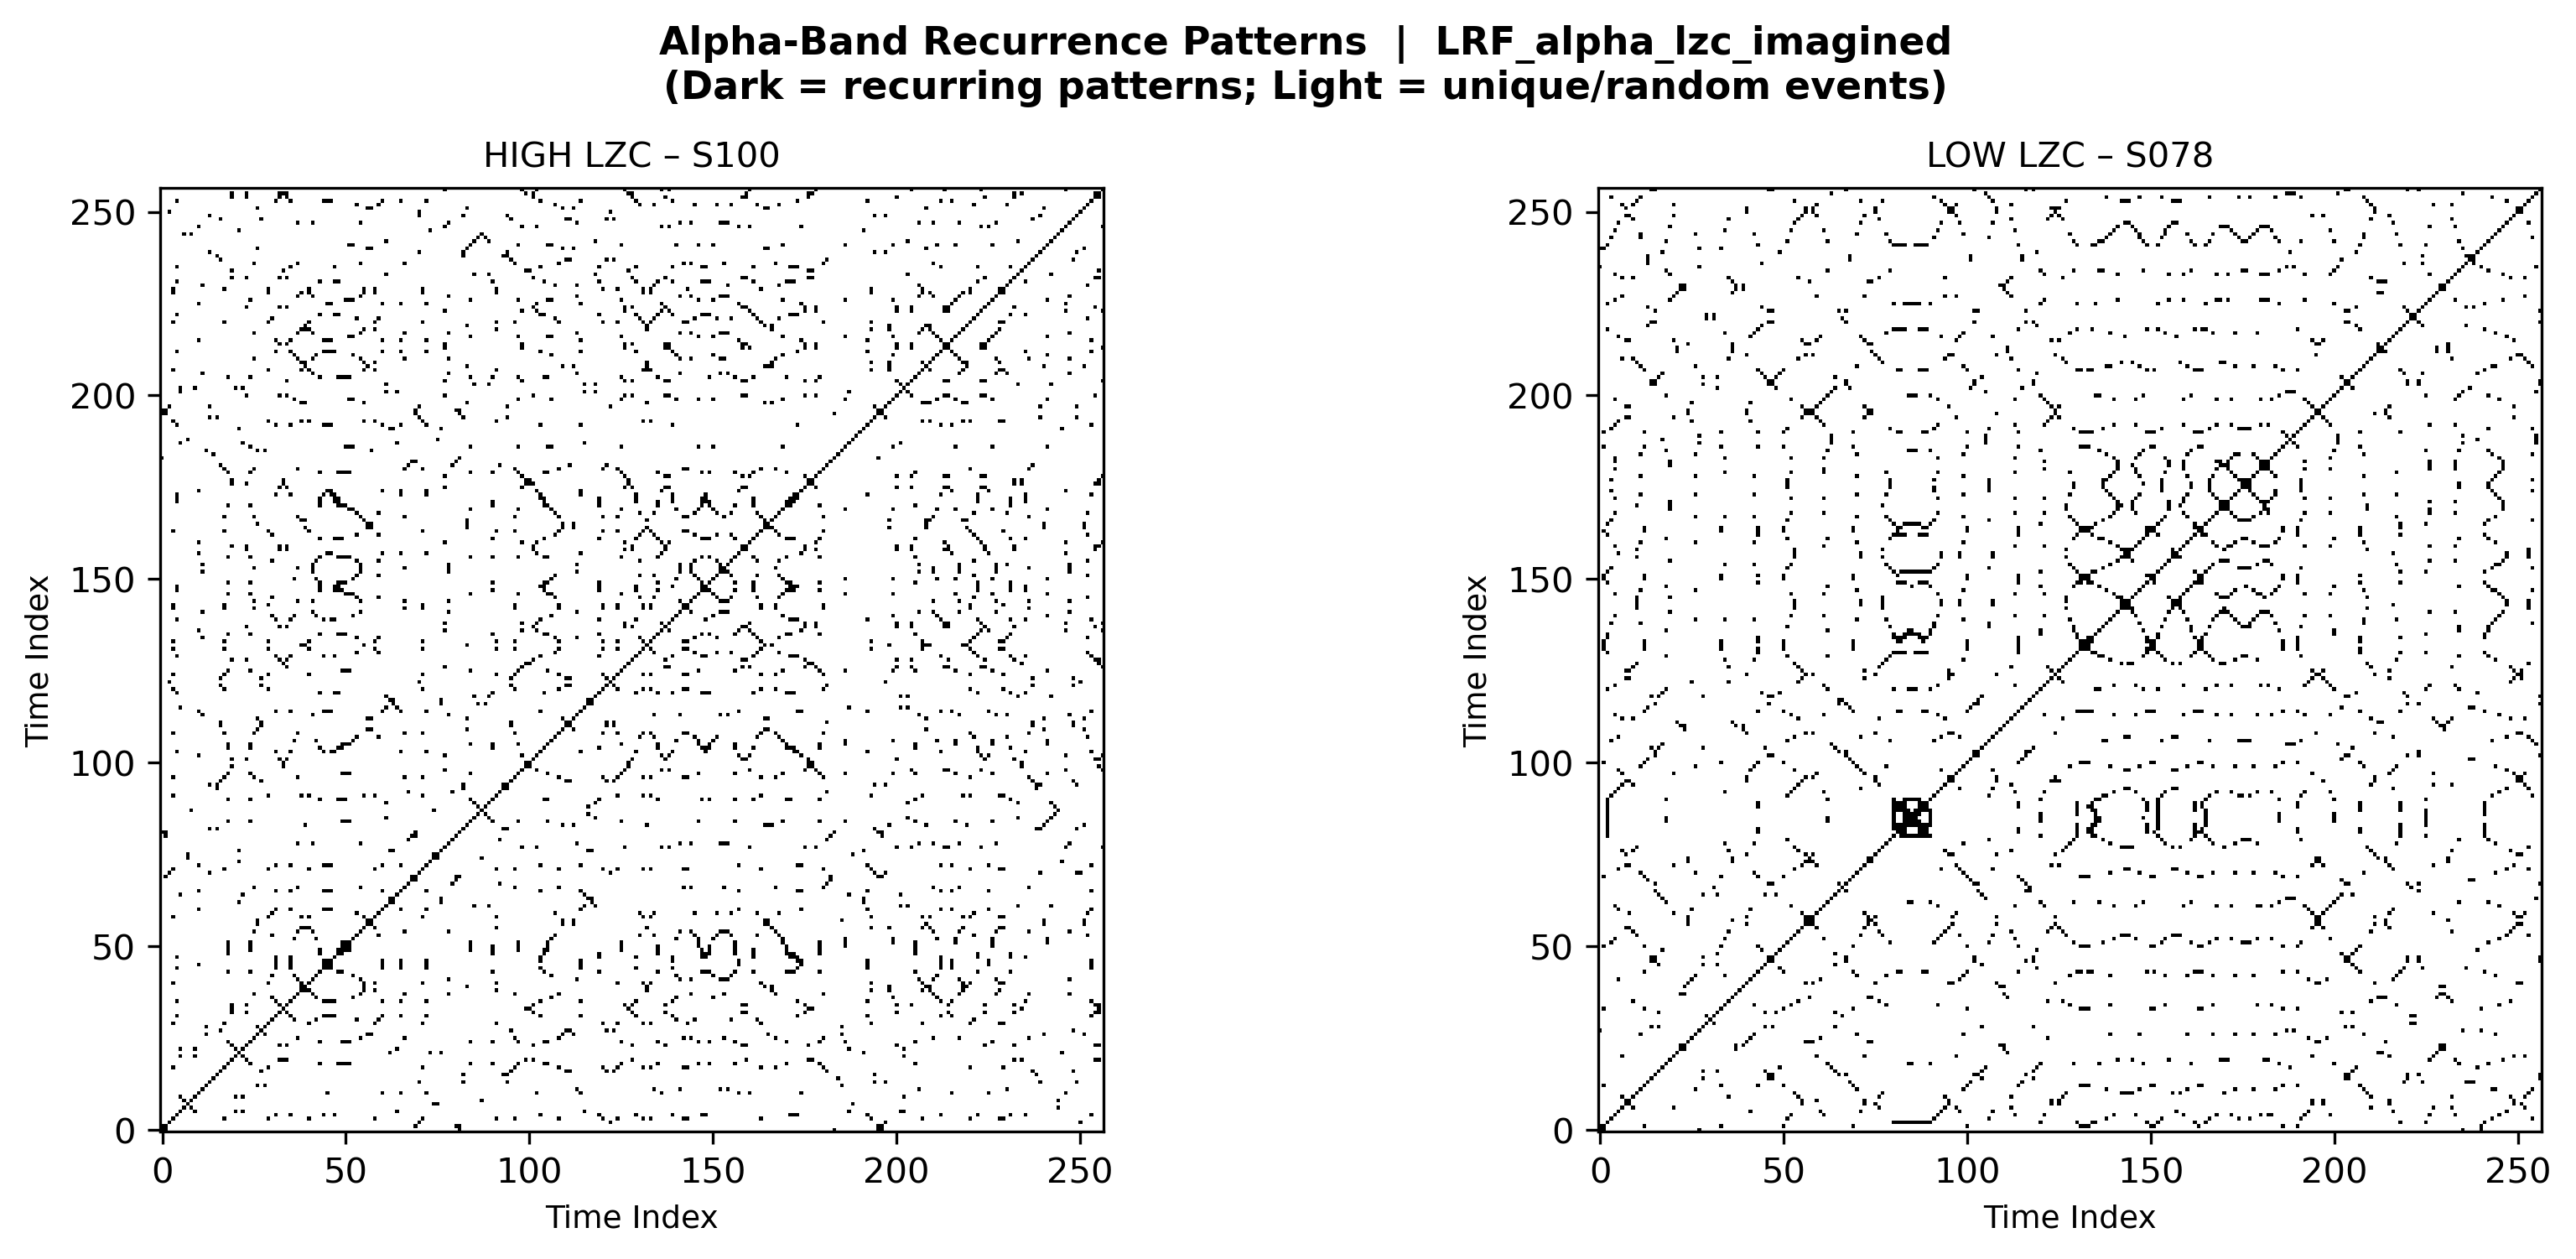

2026-03-06 04:12:47,615 - INFO - ======================================================================
2026-03-06 04:12:47,615 - INFO - LOADING DATA FOR S086 - IMAGINED VS ACTUAL ANALYSIS
2026-03-06 04:12:47,615 - INFO - ======================================================================
2026-03-06 04:12:47,616 - INFO - 
Loading baseline: eyes_open (Run 1)
2026-03-06 04:12:47,633 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-06 04:12:47,633 - INFO - 
Loading baseline: eyes_closed (Run 2)
2026-03-06 04:12:47,650 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-06 04:12:47,650 - INFO - 
Loading Left/Right Fist 1_real (Run 3)
2026-03-06 04:12:47,673 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,673 - INFO - 
Loading Left/Right Fist 1_imagined (Run 4)
2026-03-06 04:12:47,697 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,698 - INFO - 
Loading Fists/Feet 1_real (Run 5)
2026-03-06 04:12:47,719 - INFO -   ✓ Loaded: 29 epochs, 3 channels
20


LRF_tar_imagined | 1st-high: S086 | 1st-low: S018


2026-03-06 04:12:47,832 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,832 - INFO - 
Loading Left/Right Fist 3_real (Run 11)
2026-03-06 04:12:47,854 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,855 - INFO - 
Loading Left/Right Fist 3_imagined (Run 12)
2026-03-06 04:12:47,882 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,882 - INFO - 
Loading Fists/Feet 3_real (Run 13)
2026-03-06 04:12:47,903 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,904 - INFO - 
Loading Fists/Feet 3_imagined (Run 14)
2026-03-06 04:12:47,942 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-06 04:12:47,943 - INFO - 
✓ Successfully loaded 14 datasets
2026-03-06 04:12:47,947 - INFO - ======================================================================
2026-03-06 04:12:47,947 - INFO - LOADING DATA FOR S018 - IMAGINED VS ACTUAL ANALYSIS
2026-03-06 04:12:47,947 - INFO - ======================================================================
2026-03-06

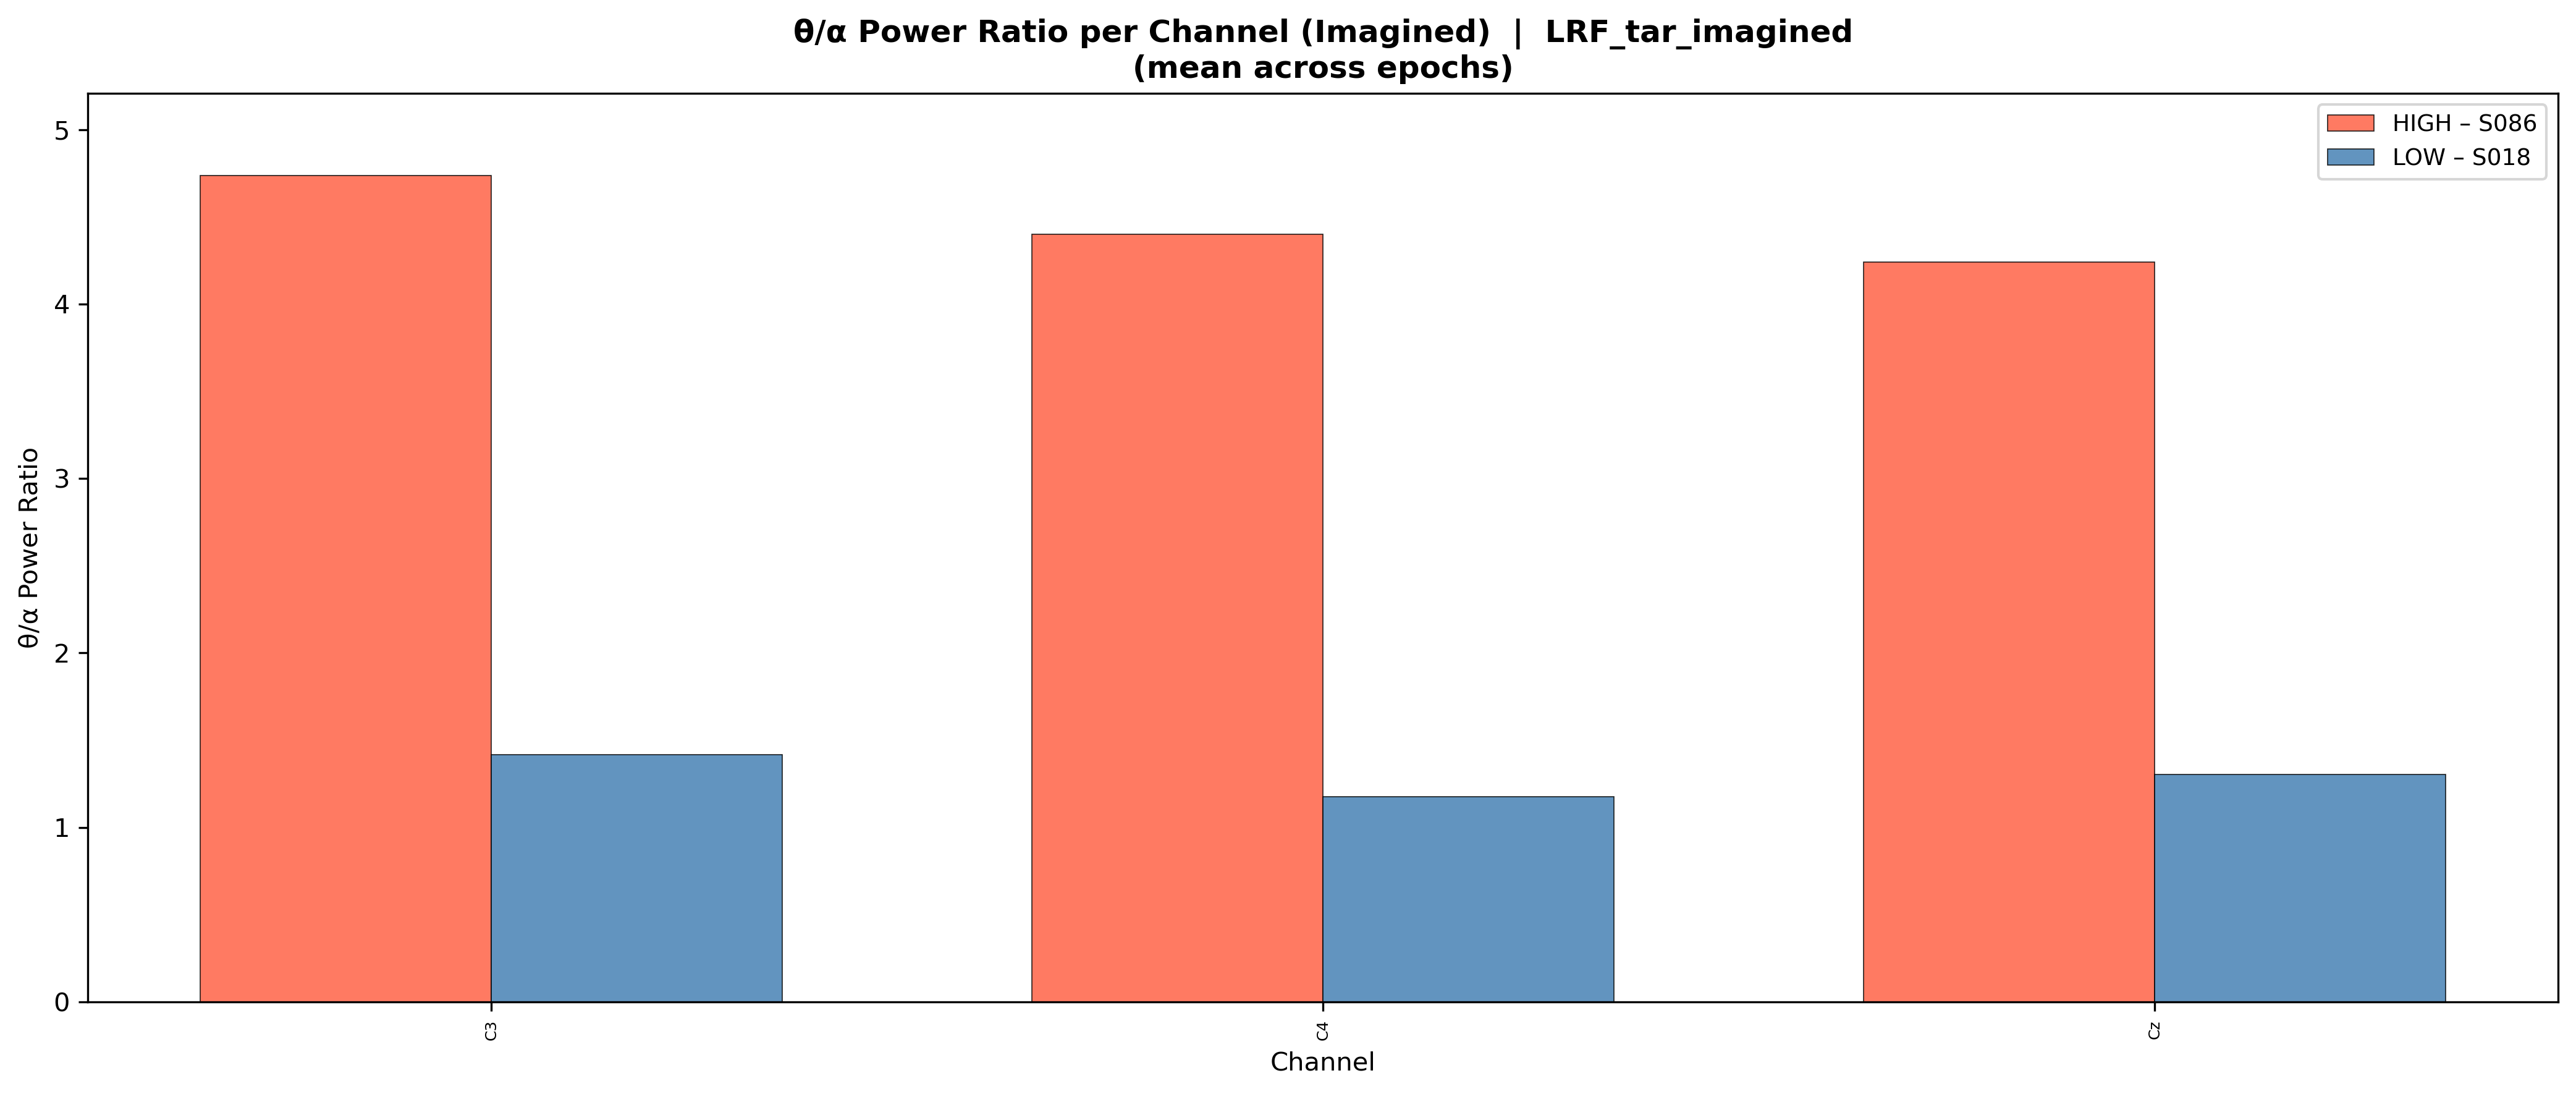

In [15]:
BASE_PATH = "eeg-motor-movementimagery-dataset-1.0.0/files"

TASK_NAME = "Left/Right Fist 1"
IMAG_KEY  = f"{TASK_NAME}_imagined"
REAL_KEY  = f"{TASK_NAME}_real"

# Read compact dataset
df_compact = pd.read_csv("eeg_features_andrew_compact_new.csv")

# Helper to get ranked subject from a sorted list
def third_subject(lst):
    if len(lst) < 3:
        raise ValueError(f"Need at least 3 subjects, got {len(lst)}: {lst}")
    return lst[2]

def first_subject(lst):
    if len(lst) < 3:
        raise ValueError(f"Need at least 3 subjects, got {len(lst)}: {lst}")
    return lst[0]

def load_subject_analyzer(subject_id):
    analyzer = ImaginedVsActualAnalyzer(subject_id=subject_id, base_path=BASE_PATH)
    analyzer.load_and_preprocess_data()
    return analyzer

def get_lrf_epochs(analyzer):
    if REAL_KEY not in analyzer.data:
        raise KeyError(f"Missing {REAL_KEY} for {analyzer.subject_id}")
    if IMAG_KEY not in analyzer.data:
        raise KeyError(f"Missing {IMAG_KEY} for {analyzer.subject_id}")
    return analyzer.data[REAL_KEY]["epochs"], analyzer.data[IMAG_KEY]["epochs"]

def get_lrf_raw(analyzer, which="imagined"):
    key = IMAG_KEY if which == "imagined" else REAL_KEY
    if key not in analyzer.data:
        raise KeyError(f"Missing {key} for {analyzer.subject_id}")
    return analyzer.data[key]["raw"]


# LRF Motor Imagery features
# LRF_alpha_lzc_imagined LZC recurrence plot
feat = "LRF_alpha_lzc_imagined"
subj_high = first_subject(df_compact.nlargest(3, feat)["subject_id"].tolist())
subj_low  = first_subject(df_compact.nsmallest(3, feat)["subject_id"].tolist())
print(f"\n{feat} | 1st-high: {subj_high} | 1st-low: {subj_low}")
ana_high = load_subject_analyzer(subj_high)
ana_low  = load_subject_analyzer(subj_low)
_, imag_high = get_lrf_epochs(ana_high)
_, imag_low  = get_lrf_epochs(ana_low)
plot_lzc_recurrence_pair(imag_high, subj_high, imag_low, subj_low, feat)



# LRF_tar_imagined θ/α ratio bar chart
feat = "LRF_tar_imagined"
subj_high = first_subject(df_compact.nlargest(3, feat)["subject_id"].tolist())
subj_low  = first_subject(df_compact.nsmallest(3, feat)["subject_id"].tolist())
print(f"\n{feat} | 1st-high: {subj_high} | 1st-low: {subj_low}")
_, imag_high = get_lrf_epochs(load_subject_analyzer(subj_high))
_, imag_low  = get_lrf_epochs(load_subject_analyzer(subj_low))
plot_tar_bar_pair(imag_high, subj_high, imag_low, subj_low, feat)


High vs Low Lempel Ziv is very hard to visualize because brain signals and EEG oscillations are inherently rhythmic, and so visualizations for even a high LZC signal will still look quite similar to those for low LZC signals. The differences are subtle but our low LZC visualization does have slightly clearer block-like structures, more consistent repeating motifs, and more extended diagonal segments compared to the high LZC vis.

2026-03-05 18:48:22,602 - INFO - ======================================================================
2026-03-05 18:48:22,603 - INFO - LOADING DATA FOR S033 - IMAGINED VS ACTUAL ANALYSIS
2026-03-05 18:48:22,603 - INFO - ======================================================================
2026-03-05 18:48:22,607 - INFO - 
Loading baseline: eyes_open (Run 1)
2026-03-05 18:48:22,699 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-05 18:48:22,699 - INFO - 
Loading baseline: eyes_closed (Run 2)
2026-03-05 18:48:22,717 - INFO -   ✓ Loaded baseline: 61.0s, 3 channels
2026-03-05 18:48:22,717 - INFO - 
Loading Left/Right Fist 1_real (Run 3)
2026-03-05 18:48:22,743 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,744 - INFO - 
Loading Left/Right Fist 1_imagined (Run 4)
2026-03-05 18:48:22,770 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,771 - INFO - 
Loading Fists/Feet 1_real (Run 5)
2026-03-05 18:48:22,795 - INFO -   ✓ Loaded: 29 epochs, 3 channels
20


LRF_alpha_entropy_imagined | 1st-high: S033 | 1st-low: S031


2026-03-05 18:48:22,840 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,840 - INFO - 
Loading Left/Right Fist 2_real (Run 7)
2026-03-05 18:48:22,882 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,886 - INFO - 
Loading Left/Right Fist 2_imagined (Run 8)
2026-03-05 18:48:22,938 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,939 - INFO - 
Loading Fists/Feet 2_real (Run 9)
2026-03-05 18:48:22,979 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:22,980 - INFO - 
Loading Fists/Feet 2_imagined (Run 10)
2026-03-05 18:48:23,020 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:23,020 - INFO - 
Loading Left/Right Fist 3_real (Run 11)
2026-03-05 18:48:23,055 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:23,056 - INFO - 
Loading Left/Right Fist 3_imagined (Run 12)
2026-03-05 18:48:23,098 - INFO -   ✓ Loaded: 29 epochs, 3 channels
2026-03-05 18:48:23,099 - INFO - 
Loading Fists/Feet 3_real (Run 13)
2026-03-05 18:48:23

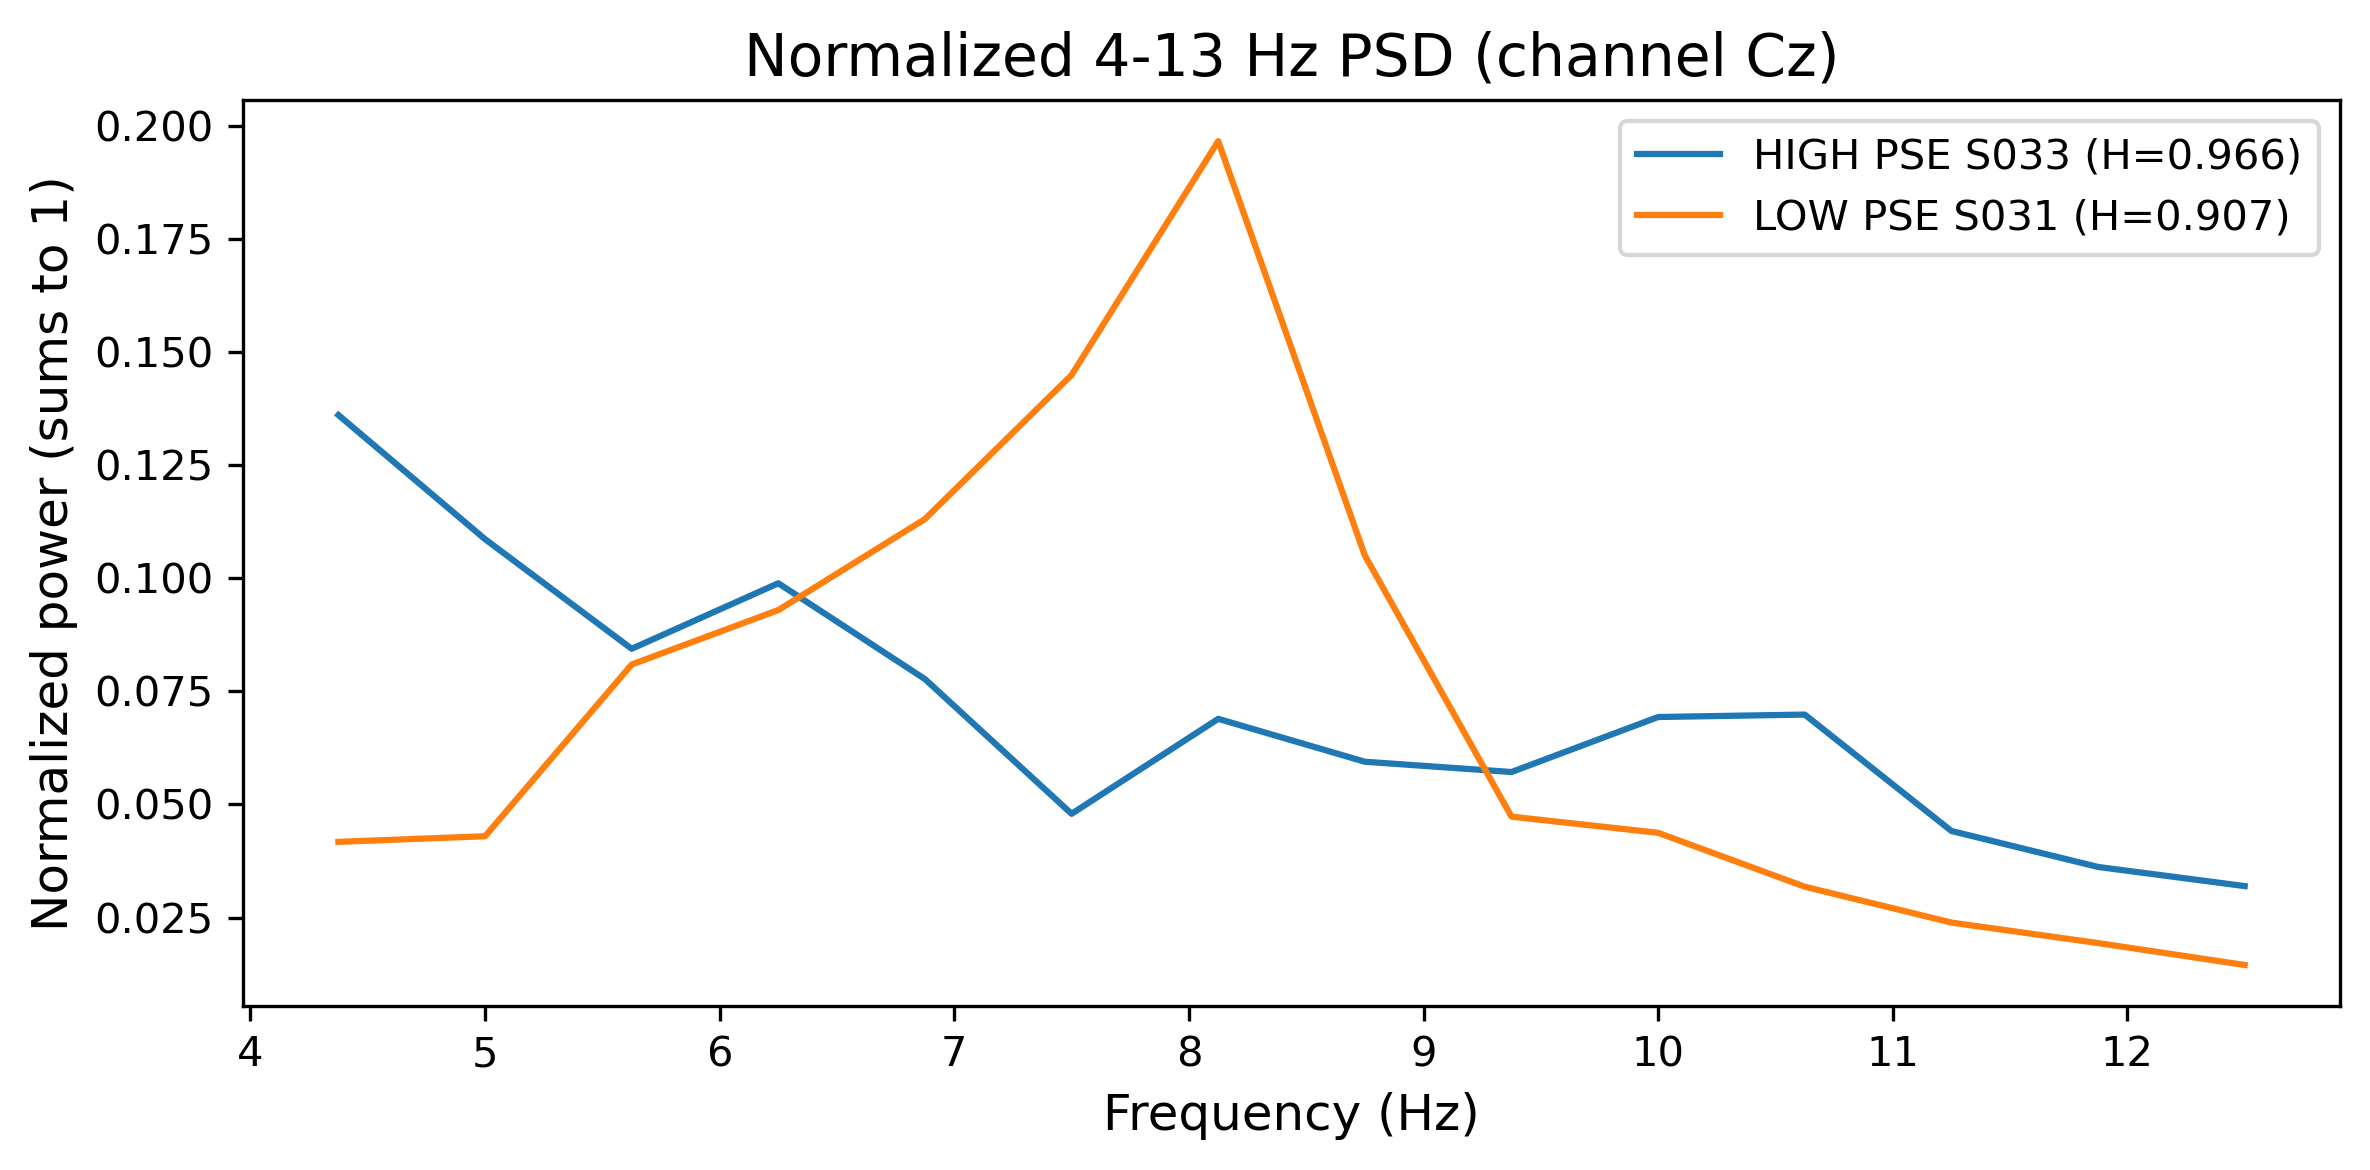

In [ ]:
from mne.time_frequency import psd_array_welch


def plot_pse_psd_compare(epochs_high, subj_high, epochs_low, subj_low,
                         fmin=4, fmax=13, pick="C3",
                         tmin=ANALYSIS_TMIN, tmax=ANALYSIS_TMAX,
                         sfreq=160, n_fft=256, n_overlap=128):
    def subject_norm_psd_and_entropy(epochs, pick):
        ep = crop_epochs_safe(epochs).copy()
        ep = ep.crop(tmin=tmin, tmax=tmax)
        x = ep.get_data(picks=[pick])[:, 0, :]  # (n_epochs, n_times)

        psds, freqs = psd_array_welch(
            x, sfreq=ep.info["sfreq"],
            fmin=fmin, fmax=fmax,
            n_fft=n_fft, n_overlap=n_overlap,
            average="mean"
        )  # psds: (n_epochs, n_freqs)

        psd_mean = psds.mean(axis=0)            # average across epochs
        p = psd_mean / (psd_mean.sum() + 1e-12) # normalize across freqs
        H = -(p * np.log2(p + 1e-12)).sum() / np.log2(len(p))
        return freqs, p, H

    freqs_h, p_h, H_h = subject_norm_psd_and_entropy(epochs_high, pick)
    freqs_l, p_l, H_l = subject_norm_psd_and_entropy(epochs_low, pick)

    plt.figure(figsize=(8,4))
    plt.plot(freqs_h, p_h, label=f"HIGH PSE {subj_high} (H={H_h:.3f})")
    plt.plot(freqs_l, p_l, label=f"LOW PSE {subj_low} (H={H_l:.3f})")
    plt.title(f"Normalized {fmin}-{fmax} Hz PSD (channel {pick})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized power (sums to 1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot this graph for the same HIGH and LOW subjects from LRF_alpha_entropy_imagined
feat = "LRF_alpha_entropy_imagined"
subj_high = first_subject(df_compact.nlargest(3, feat)["subject_id"].tolist())
subj_low  = first_subject(df_compact.nsmallest(3, feat)["subject_id"].tolist())
print(f"\n{feat} | 1st-high: {subj_high} | 1st-low: {subj_low}")
ana_high = load_subject_analyzer(subj_high)
ana_low  = load_subject_analyzer(subj_low)
_, imag_high = get_lrf_epochs(ana_high)
_, imag_low  = get_lrf_epochs(ana_low)
plot_pse_psd_compare(imag_high, subj_high, imag_low, subj_low,  fmin=4, fmax=13, pick="Cz")

In [ ]:
subj_high = first_subject(df_compact.nlargest(3, feat)["subject_id"].tolist())
subj_low  = first_subject(df_compact.nsmallest(3, feat)["subject_id"].tolist())

subj_high = df_compact.nlargest(1, feat)["subject_id"].iloc[0]
subj_low  = df_compact.nsmallest(1, feat)["subject_id"].iloc[0]
subj_high, subj_low

('S033', 'S031')

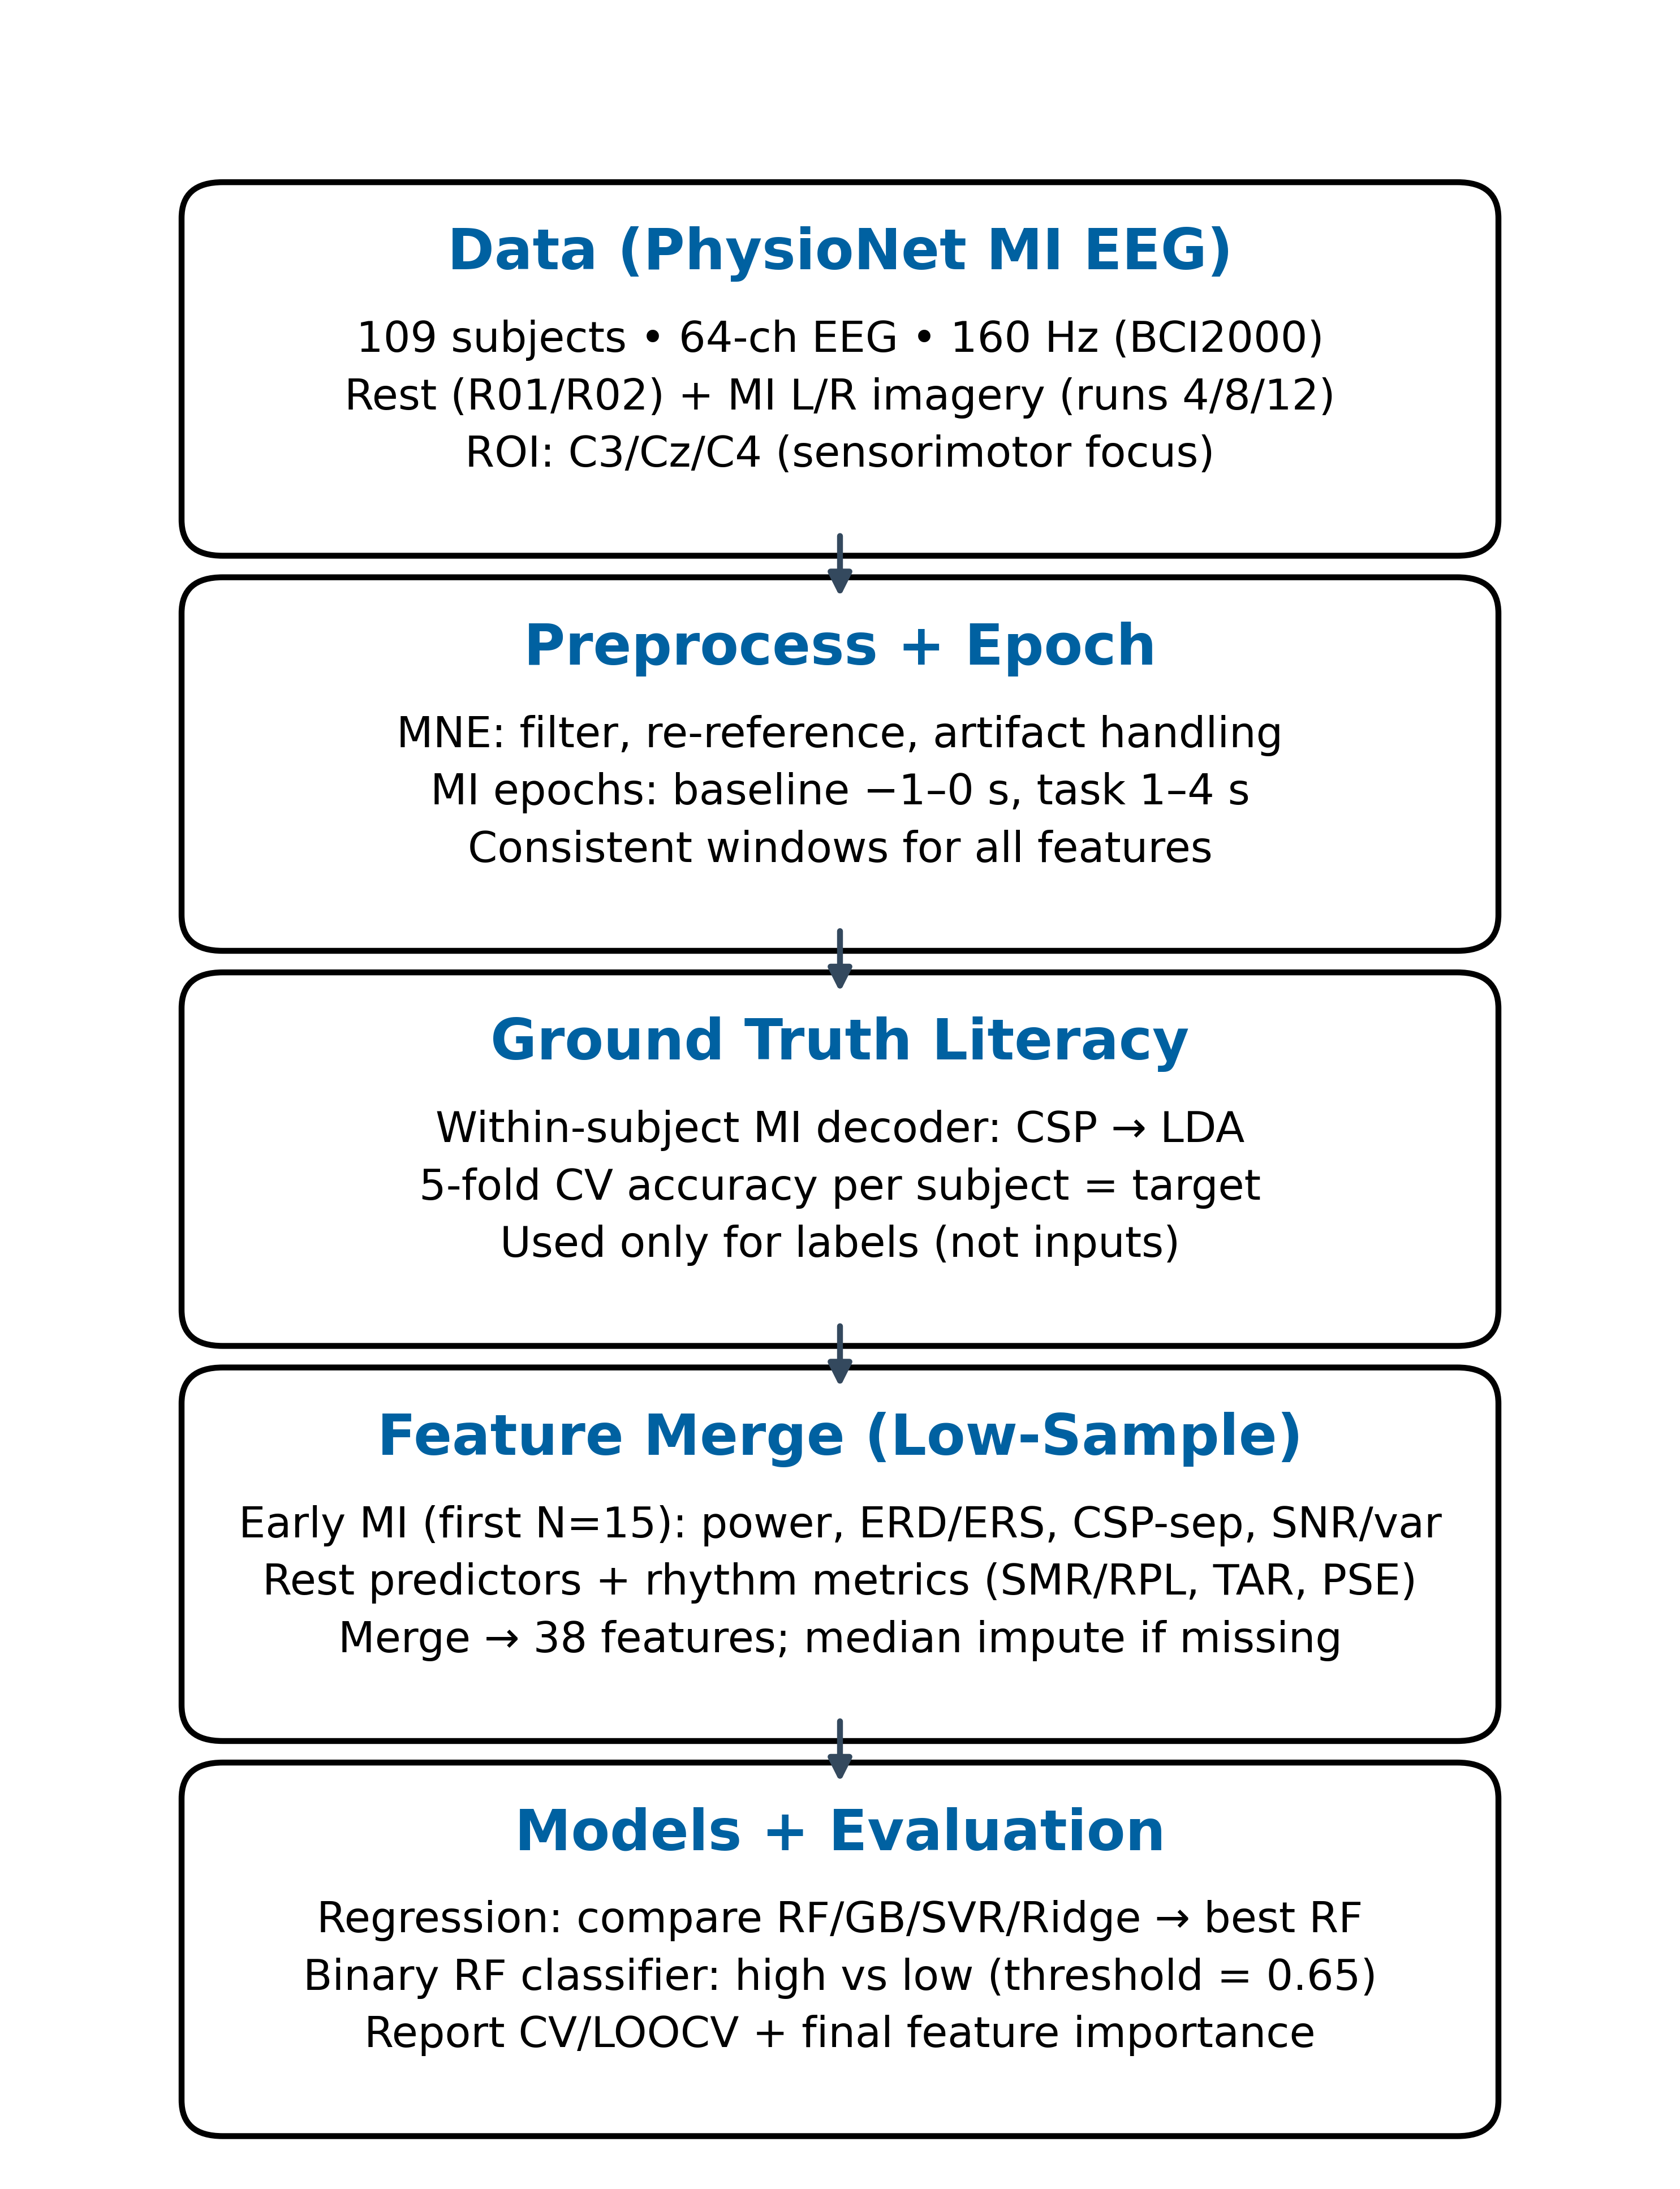

In [ ]:
def create_pipeline_diagram():
    fig, ax = plt.subplots(figsize=(10, 13))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 15)
    ax.axis("off")

    # Box layout
    box_width = 7.5
    box_height = 2.1
    center_x = 5
    start_y = 13.6
    vertical_gap = 2.75

    # 5 boxes, <=3 lines each
    boxes = [
        {
            "title": "Data (PhysioNet MI EEG)",
            "content": (
                "109 subjects • 64-ch EEG • 160 Hz (BCI2000)\n"
                "Rest (R01/R02) + MI L/R imagery (runs 4/8/12)\n"
                "ROI: C3/Cz/C4 (sensorimotor focus)"
            )
        },
        {
            "title": "Preprocess + Epoch",
            "content": (
                "MNE: filter, re-reference, artifact handling\n"
                "MI epochs: baseline −1–0 s, task 1–4 s\n"
                "Consistent windows for all features"
            )
        },
        {
            "title": "Ground Truth Literacy",
            "content": (
                "Within-subject MI decoder: CSP → LDA\n"
                "5-fold CV accuracy per subject = target\n"
                "Used only for labels (not inputs)"
            )
        },
        {
            "title": "Feature Merge (Low-Sample)",
            "content": (
                "Early MI (first N=15): power, ERD/ERS, CSP-sep, SNR/var\n"
                "Rest predictors + rhythm metrics (SMR/RPL, TAR, PSE)\n"
                "Merge → 38 features; median impute if missing"
            )
        },
        {
            "title": "Models + Evaluation",
            "content": (
                "Regression: compare RF/GB/SVR/Ridge → best RF\n"
                "Binary RF classifier: high vs low (threshold = 0.65)\n"
                "Report CV/LOOCV + final feature importance"
            )
        }
    ]

    for i, box in enumerate(boxes):
        y_top = start_y - i * vertical_gap

        rect = patches.FancyBboxPatch(
            (center_x - box_width/2, y_top - box_height),
            box_width, box_height,
            boxstyle="round,pad=0.25",
            edgecolor="#000000",
            facecolor="#ffffff",
            lw=2.5
        )
        ax.add_patch(rect)

        ax.text(
            center_x, y_top - 0.25, box["title"],
            ha="center", va="center",
            fontsize=24, fontweight="bold",
            color="#0061a1"
        )

        ax.text(
            center_x, y_top - 1.25, box["content"],
            ha="center", va="center",
            fontsize=18, linespacing=1.5
        )

        if i < len(boxes) - 1:
            arrow_start_y = y_top - box_height - 0.08
            arrow_end_y = (start_y - (i+1) * vertical_gap) + 0.08
            ax.annotate(
                "",
                xy=(center_x, arrow_end_y),
                xytext=(center_x, arrow_start_y),
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=2.5,
                    color="#34495e",
                    mutation_scale=20
                )
            )

    plt.tight_layout()
    plt.savefig("pipeline_visualization.png", dpi=300, bbox_inches="tight")
    plt.show()

create_pipeline_diagram()

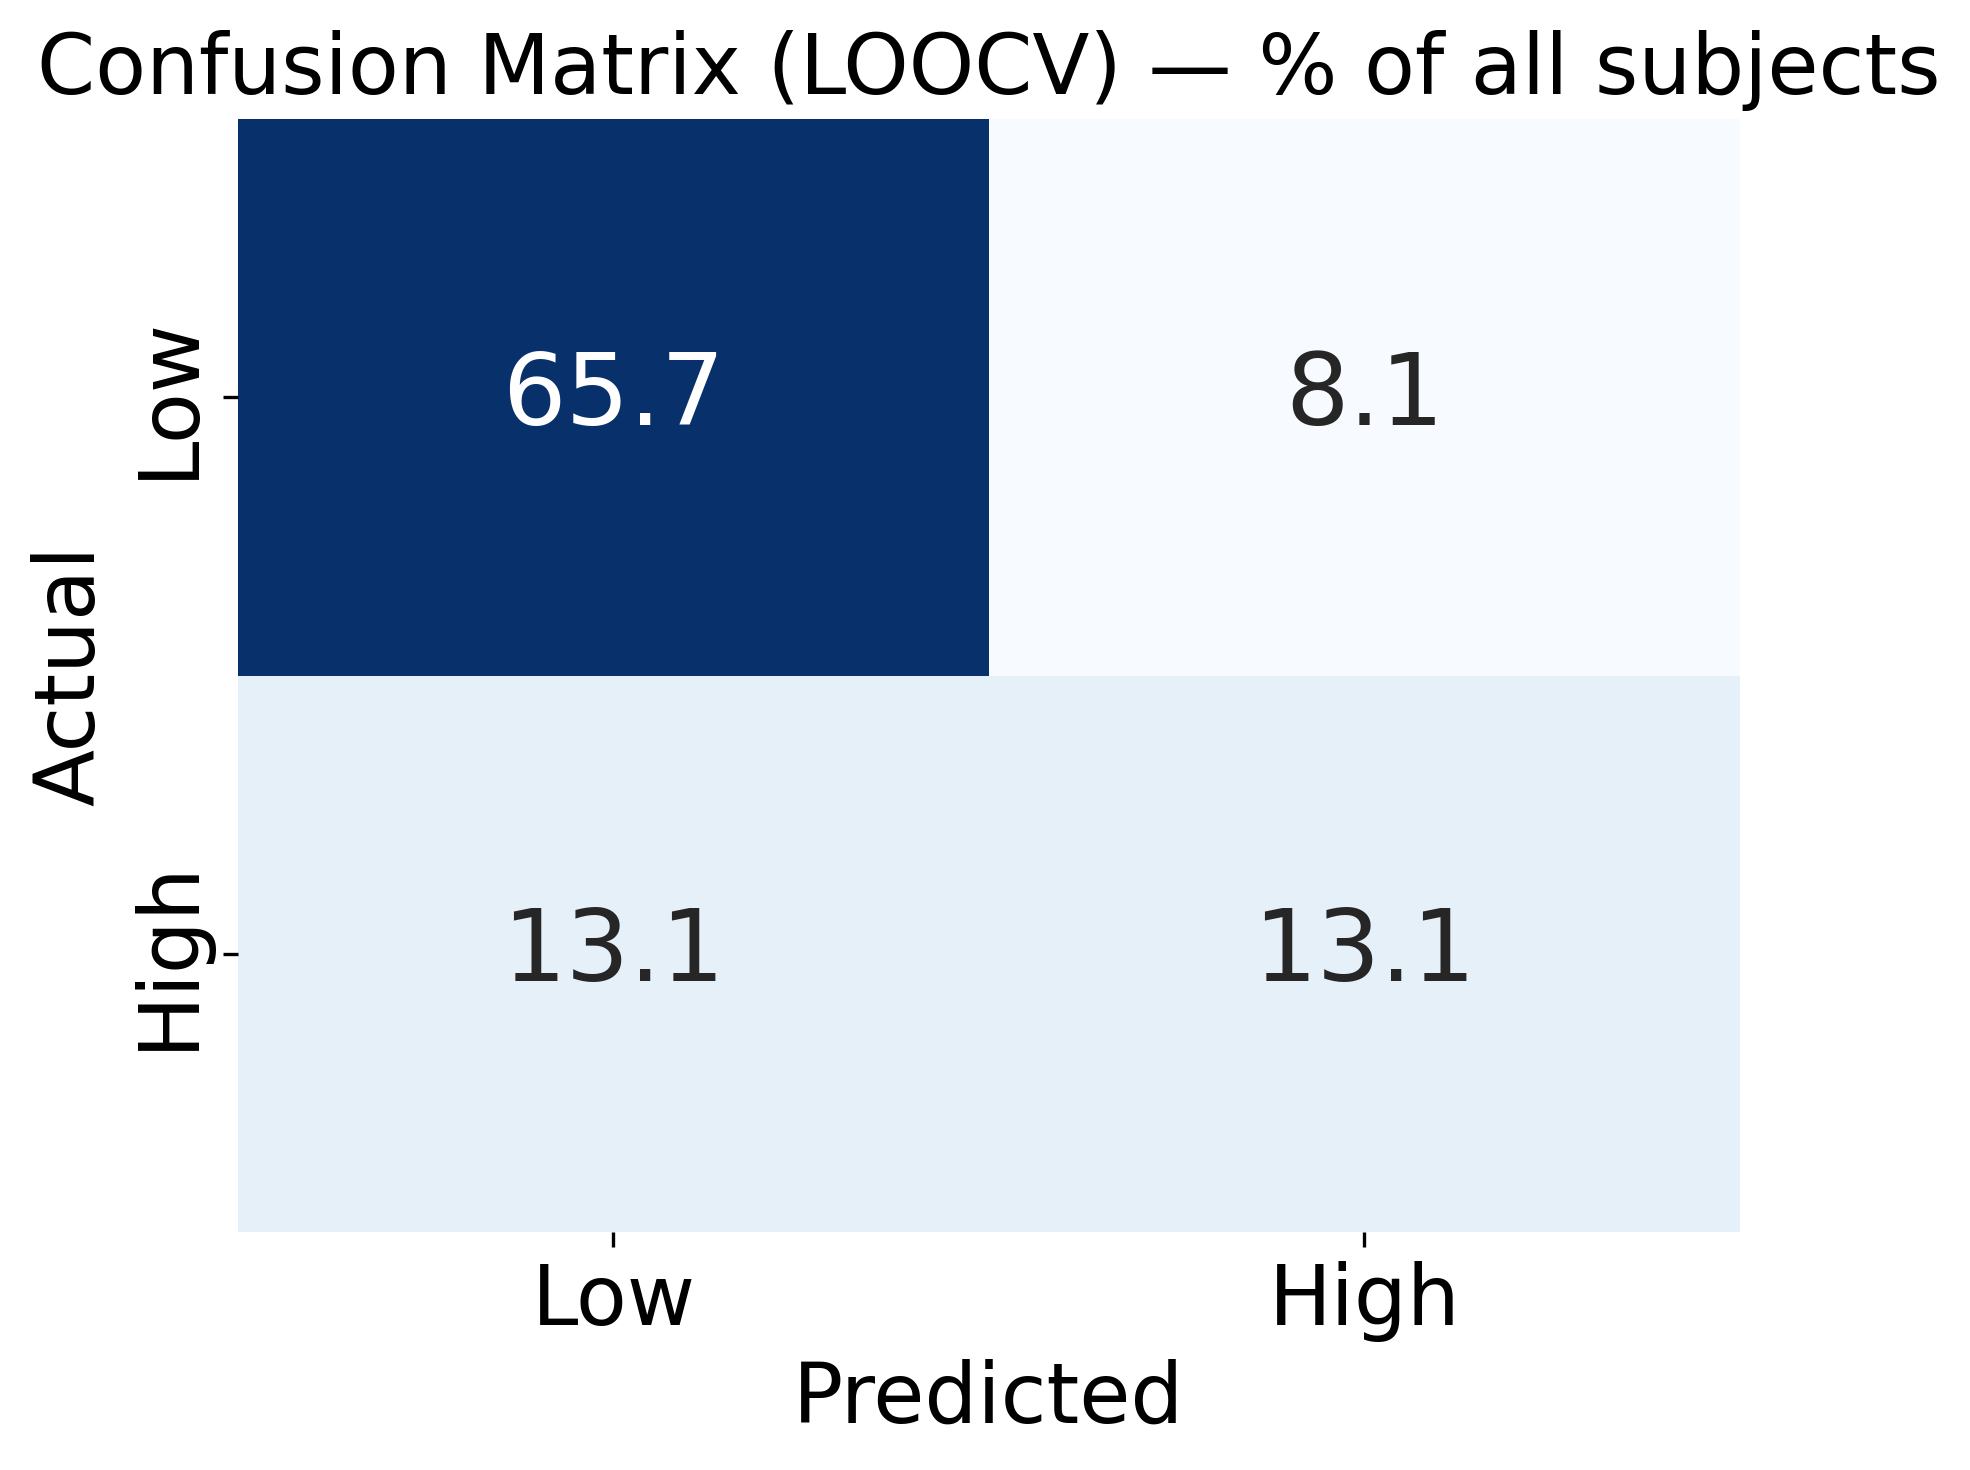

In [ ]:
import json
import seaborn as sns

with open("rf_classifier_metadata.json", "r") as f:
    meta = json.load(f)

cm = np.array(meta["confusion_matrix"], dtype=int)
cm_pct = cm.astype(float) / cm.sum() * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"],
    ax=ax,
    cbar=False,
    annot_kws={"size": 24},
)
ax.set_xlabel("Predicted", fontsize=20)
ax.set_ylabel("Actual", fontsize=20)
ax.set_title("Confusion Matrix (LOOCV) — % of all subjects", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.show()

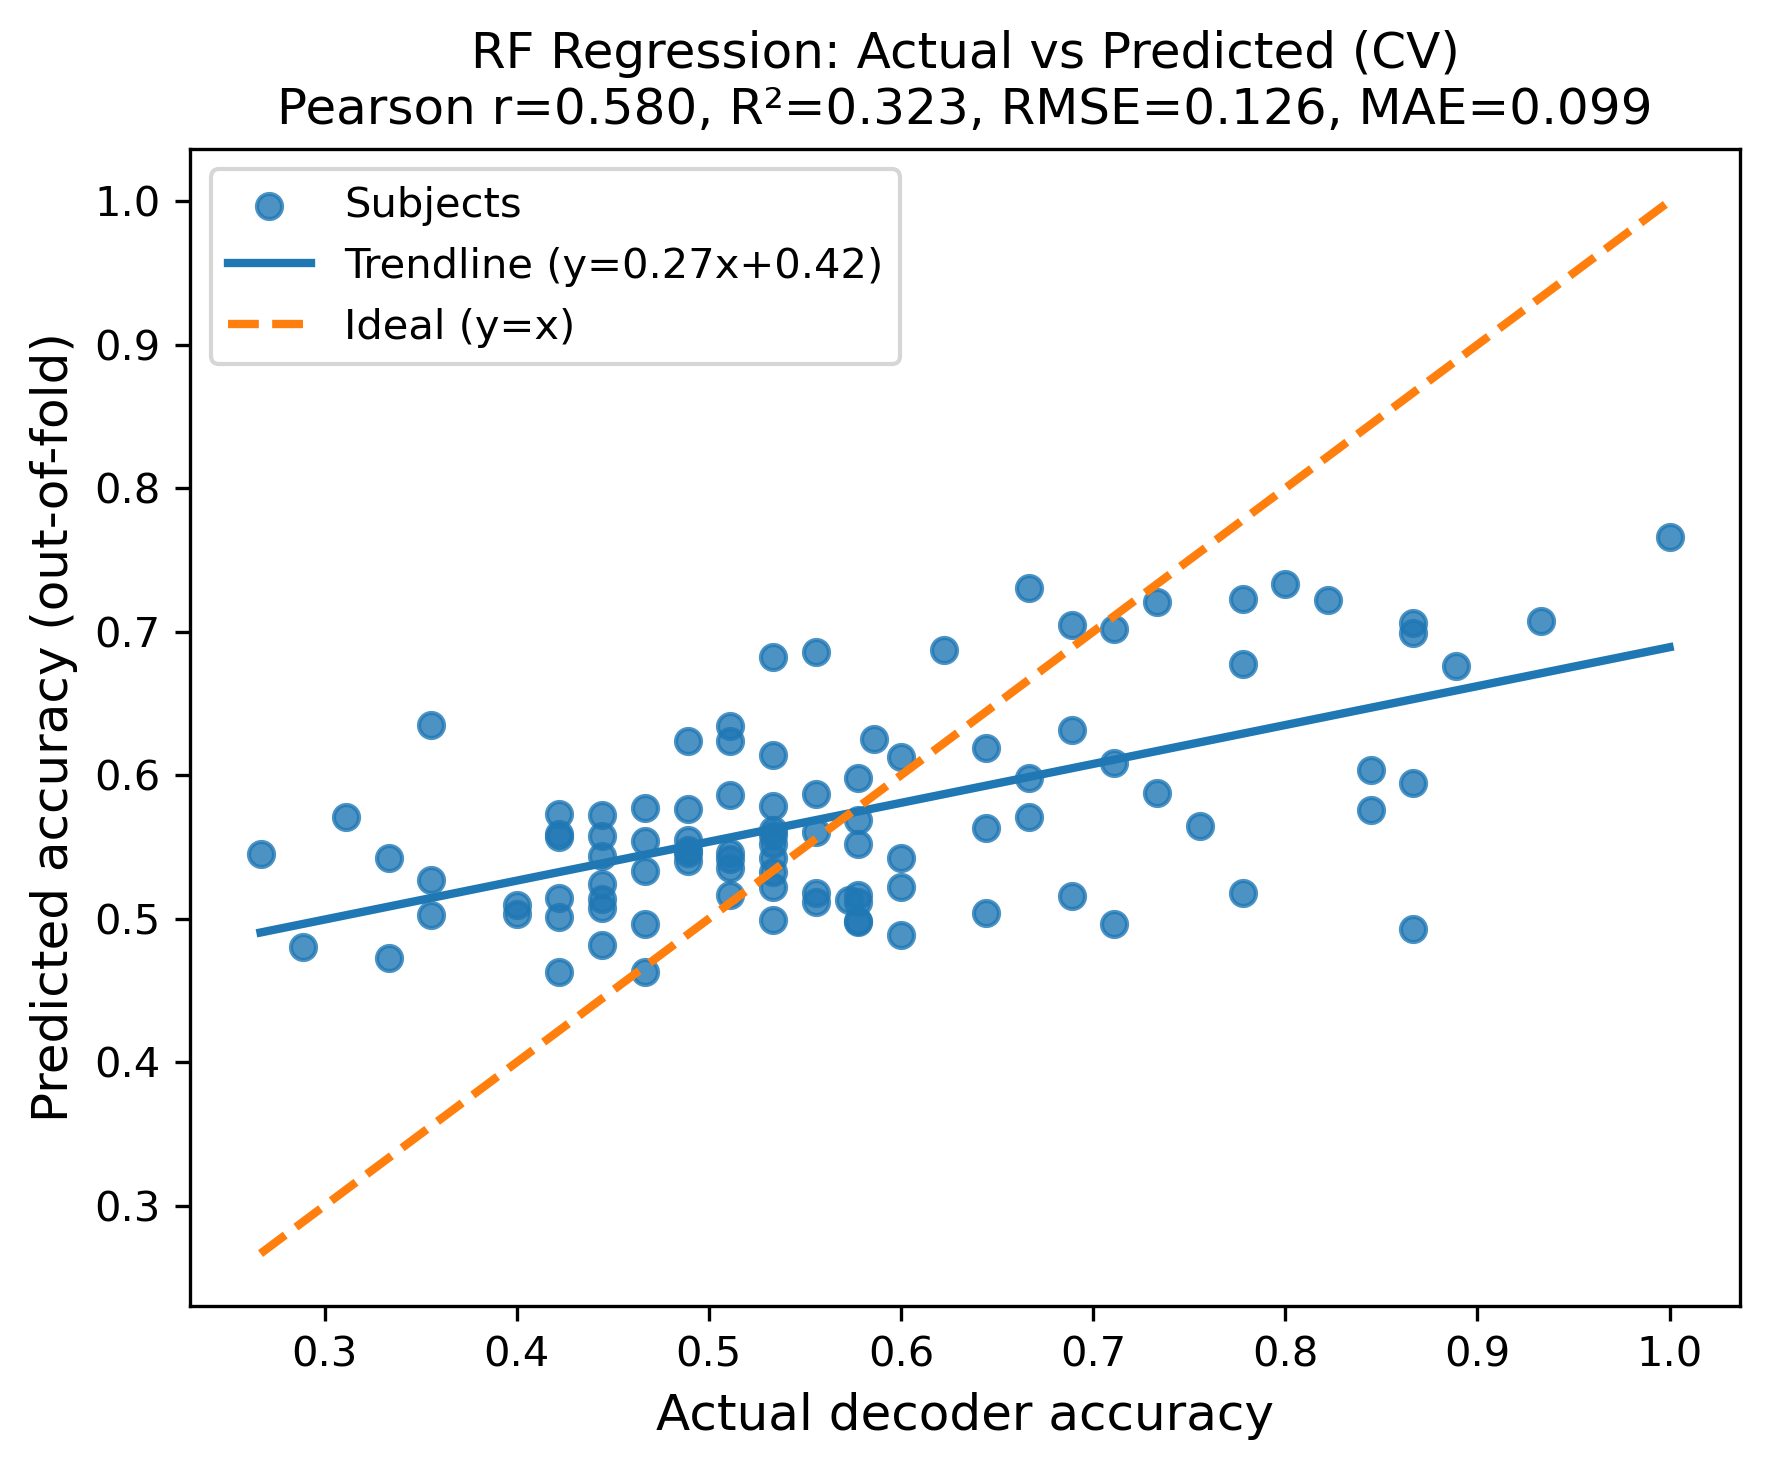

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Load regression evaluation + selected features
with open("model_evaluation copy.json", "r") as f:
    me = json.load(f)

meta = me["metadata"]
selected_features = meta["selected_features"]
subject_ids = me["subject_ids"]
y_true = np.array(me["models"]["Random Forest"]["actual"], dtype=float)

# Load merged per-subject features
with open("early_trial_features_merged copy.json", "r") as f:
    merged = json.load(f)

feat_by_subj = {int(s["subject_id"]): s["feature_dict"] for s in merged["subjects"]}

# Build X in the same subject order
X = np.array([[feat_by_subj[sid][fn] for fn in selected_features] for sid in subject_ids], dtype=float)

# Scale (matches your current pipeline behavior)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

cv = KFold(n_splits=meta.get("n_folds", 5), shuffle=True, random_state=meta.get("random_state", 42))
y_pred = cross_val_predict(rf, X_scaled, y_true, cv=cv)  # out-of-fold predictions

# Metrics for title
r, _ = pearsonr(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Trendline
m, b = np.polyfit(y_true, y_pred, 1)
x_line = np.linspace(y_true.min(), y_true.max(), 200)
trend = m * x_line + b

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true, y_pred, alpha=0.8, label="Subjects")
ax.plot(x_line, trend, linewidth=2, label=f"Trendline (y={m:.2f}x+{b:.2f})")
ax.plot(x_line, x_line, linestyle="--", linewidth=2, label="Ideal (y=x)")

ax.set_xlabel("Actual decoder accuracy", fontsize=12)
ax.set_ylabel("Predicted accuracy (out-of-fold)", fontsize=12)
ax.set_title(
    f"RF Regression: Actual vs Predicted (CV)\nPearson r={r:.3f}, R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}",
    fontsize=12,
)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:


models = ["Random Forest", "Gradient Boosting", "SVM", "Ridge Regression"]

metrics = {
    "RMSE":  {"mean": [0.1262, 0.1352, 0.1339, 0.1305], "std": [0.0696, 0.0730, 0.0848, 0.0819], "lower_better": True},
    "MAE":   {"mean": [0.0992, 0.1065, 0.1046, 0.1013], "std": [0.0150, 0.0170, 0.0211, 0.0165], "lower_better": True},
    "R²":    {"mean": [0.3021, 0.1689, 0.2464, 0.2690], "std": [0.0967, 0.2014, 0.1115, 0.1312], "lower_better": False},
    "Pearson r": {"mean": [0.5802, 0.5244, 0.4921, 0.5299], "std": None, "lower_better": False},
}

def plot_metric(name, means, stds=None, lower_better=False, save_path=None):
    x = np.arange(len(models))
    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    if stds is not None:
        bars = ax.bar(x, means, yerr=stds, capsize=5)
    else:
        bars = ax.bar(x, means)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylabel(name)
    ax.set_title(f"{name} by model" + (" (lower is better)" if lower_better else " (higher is better)"))

    for i, b in enumerate(bars):
        h = b.get_height()
        if stds is not None:
            ax.text(b.get_x() + b.get_width()/2, h, f"{means[i]:.4f}\n±{stds[i]:.4f}",
                    ha="center", va="bottom", fontsize=9)
        else:
            ax.text(b.get_x() + b.get_width()/2, h, f"{means[i]:.4f}",
                    ha="center", va="bottom", fontsize=9)

    ax.margins(y=0.15)
    plt.tight_layout()

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 1600  =      0.000 ...    10.000 secs...


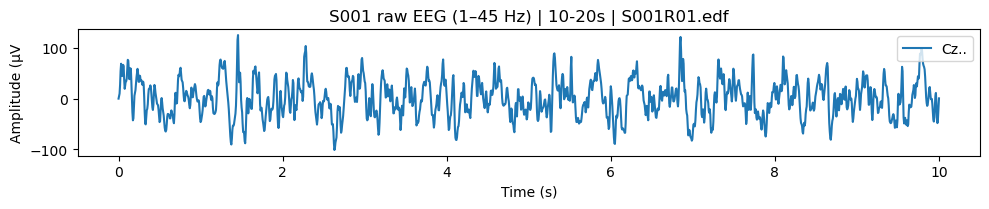

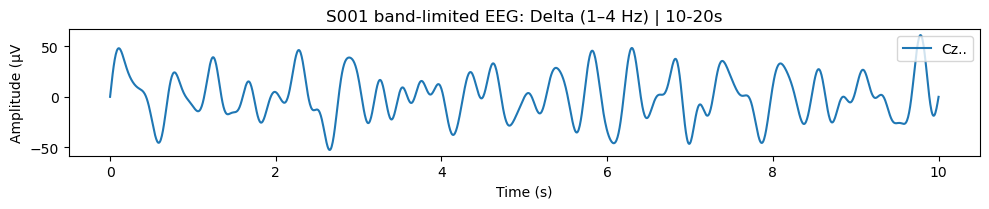

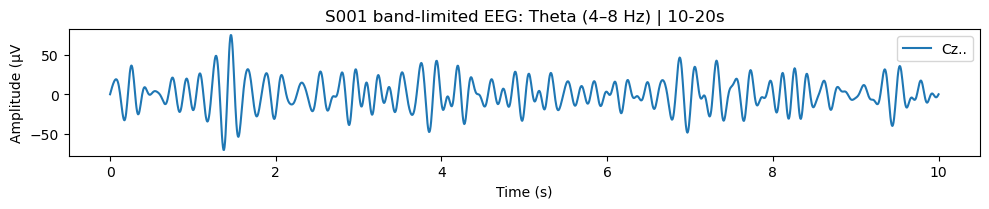

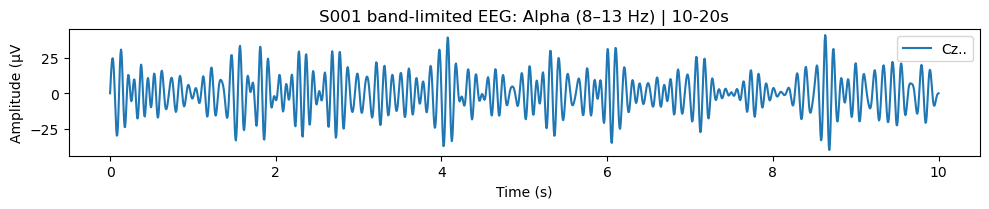

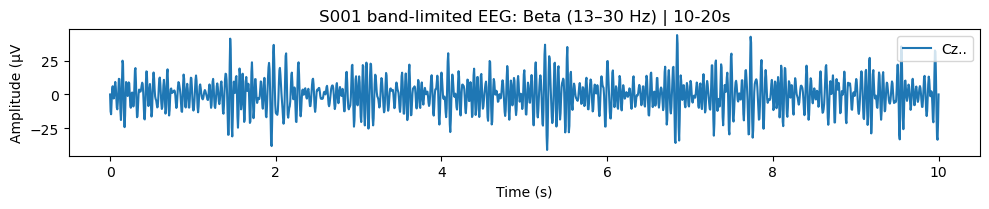

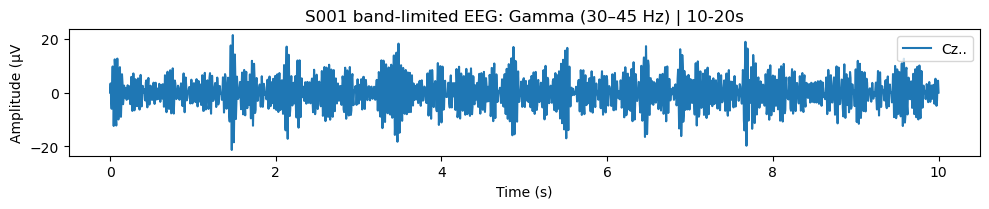

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne

base = Path("eeg-motor-movementimagery-dataset-1.0.0/files")
edf_path = base / "S001" / "S001R01.edf"  # eyes open resting
# edf_path = base / "S001" / "S001R02.edf"  # eyes closed resting (often stronger alpha)

assert edf_path.exists(), f"Missing EDF: {edf_path}"

# Settings
CHS = ["Cz.."]
TMIN, TMAX = 10, 20
OFFSET_UV = 60

BANDS = {
    "Delta (1–4 Hz)": (1, 4),
    "Theta (4–8 Hz)": (4, 8),
    "Alpha (8–13 Hz)": (8, 13),
    "Beta (13–30 Hz)": (13, 30),
    "Gamma (30–45 Hz)": (30, 45),
}

def plot_stacked(raw_segment, title, offset_uv=60):
    data = raw_segment.get_data() * 1e6  # V -> µV
    times = raw_segment.times
    fig, ax = plt.subplots(figsize=(10, 2.2))
    for i, ch in enumerate(raw_segment.ch_names):
        ax.plot(times, data[i] + i * offset_uv, label=ch)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Read EDF without preloading everything
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

# Standard montage so Cz position are known (optional for plotting)
raw.set_montage("standard_1020", on_missing="ignore")

# Crop first, then load only that segment into memory
seg = raw.copy().pick_channels(CHS).crop(tmin=TMIN, tmax=TMAX).load_data()

# Use faster IIR filtering for visualization
seg_display = seg.copy().filter(1, 45, method="iir", verbose=False)
plot_stacked(seg_display, f"S001 raw EEG (1–45 Hz) | {TMIN}-{TMAX}s | {edf_path.name}", OFFSET_UV)

for name, (lo, hi) in BANDS.items():
    seg_band = seg.copy().filter(lo, hi, method="iir", verbose=False)
    plot_stacked(seg_band, f"S001 band-limited EEG: {name} | {TMIN}-{TMAX}s", OFFSET_UV)

In [ ]:
[c for c in raw.ch_names if "C3" in c.upper() or "CZ" in c.upper() or "C4" in c.upper()]

['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..']